# Vehicle Insurance Fraud Detection
## Machine Learning Foundations — Group Project
### IE University · BDBA 2025 · May 2026

---

**Group 4:** Aoi Ueno · Estelle Arnander · José Bouza Femenia · Loraine Nieto · Manvi Gupta · Seif Omara

**Dataset:** [Angoss Vehicle Insurance Fraud Detection](https://www.kaggle.com/datasets/khusheekapoor/vehicle-insurance-fraud-detection)
**GitHub:** https://github.com/1manvi/ML-Vehicle-Insurance-Fraud-2026

---

## Research Question

*Which model and resampling strategy provide the best balance for detecting fraud under class imbalance?*

---

## Problem Statement

Vehicle insurance fraud imposes direct financial costs on insurers and indirect costs on honest policyholders through higher premiums.  The problem is the high class imbalance: 5.99% of the claims (923 out of 15,420) are fraudulent and a naive model that always predicts "legitimate" has an accuracy of 94% and fails to detect any fraud case. This project aims to compare the effectiveness of data-level responses (random oversampling, SMOTE, SMOTE-NC) and algorithm-level responses (class weighting, hyperparameter tuning, threshold optimisation) on three model families (Logistic Regression, Random Forest, XGBoost) to tackle this imbalance.

The problem is framed as a binary classification problem. PR-AUC is the most common model selection metric since it does not overestimate performance on the minority class. The most critical business metric is recall — if a fraud case is missed, a complete fraudulent payout is made. Precision is important for the business — if a false accusation, it means an unnecessary investigation and a customer risking leaving. F1 is a balance of both and is used for threshold selection.

# 1. Load data

---
## 1. Data Loading & Initial Exploration

The dataset is loaded into a pandas DataFrame to enable data manipulation and analysis. The dataset consists of 15,420 insurance claims described by 32 features, including 25 categorical and 6 ordinal variables. Each row represents a single insurance claim with observations on temporal information, vehicle characteristics, policy details, and claim statuses.

Column names are standardised to lowercase with underscores. This improves code readability and consistency, and reduces the risk of syntax or referencing errors throughout the preprocessing and modelling pipeline.

In [224]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib

from sklearn.preprocessing import (
    StandardScaler,
    LabelEncoder,
    OneHotEncoder,
    OrdinalEncoder,
    MinMaxScaler,
)

from sklearn.model_selection import (
    train_test_split,
    RandomizedSearchCV,
    GridSearchCV,
    StratifiedKFold,
)

from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    average_precision_score,
    accuracy_score,
    precision_score,
    classification_report,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    PrecisionRecallDisplay,
)

from imblearn.over_sampling import RandomOverSampler, SMOTE

import xgboost as xgb

matplotlib.rcParams["figure.dpi"] = 120

from sklearn import set_config
set_config(display='text')

import warnings
from sklearn.exceptions import ConvergenceWarning

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=ConvergenceWarning)

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)



In [3]:
df = pd.read_csv("carclaims.csv")

In [4]:
df.shape

(15420, 33)

In [5]:
df.head()

,Month,WeekOfMonth,DayOfWeek,Make,AccidentArea,DayOfWeekClaimed,MonthClaimed,WeekOfMonthClaimed,Sex,MaritalStatus,...,AgeOfPolicyHolder,PoliceReportFiled,WitnessPresent,AgentType,NumberOfSuppliments,AddressChange-Claim,NumberOfCars,Year,BasePolicy,FraudFound
0,Dec,5,Wednesday,Honda,Urban,Tuesday,Jan,1,Female,Single,...,26 to 30,No,No,External,none,1 year,3 to 4,1994,Liability,No
1,Jan,3,Wednesday,Honda,Urban,Monday,Jan,4,Male,Single,...,31 to 35,Yes,No,External,none,no change,1 vehicle,1994,Collision,No
2,Oct,5,Friday,Honda,Urban,Thursday,Nov,2,Male,Married,...,41 to 50,No,No,External,none,no change,1 vehicle,1994,Collision,No
3,Jun,2,Saturday,Toyota,Rural,Friday,Jul,1,Male,Married,...,51 to 65,Yes,No,External,more than 5,no change,1 vehicle,1994,Liability,No
4,Jan,5,Monday,Honda,Urban,Tuesday,Feb,2,Female,Single,...,31 to 35,No,No,External,none,no change,1 vehicle,1994,Collision,No


---
## 2. Column Name Standardisation

Column names are converted to lowercase and special characters replaced with underscores using a regex substitution. This ensures consistent referencing across all pipeline stages and prevents errors from inconsistent capitalisation or punctuation in column names.

# Clean columns names

In [7]:
df.columns = df.columns.str.lower().str.replace('[^a-z0-9]', '_', regex=True)
print(df.columns.tolist())

['month', 'weekofmonth', 'dayofweek', 'make', 'accidentarea', 'dayofweekclaimed', 'monthclaimed', 'weekofmonthclaimed', 'sex', 'maritalstatus', 'age', 'fault', 'policytype', 'vehiclecategory', 'vehicleprice', 'policynumber', 'repnumber', 'deductible', 'driverrating', 'days_policy_accident', 'days_policy_claim', 'pastnumberofclaims', 'ageofvehicle', 'ageofpolicyholder', 'policereportfiled', 'witnesspresent', 'agenttype', 'numberofsuppliments', 'addresschange_claim', 'numberofcars', 'year', 'basepolicy', 'fraudfound']


---
## 3. Data Leakage and Useless Column Removal

Several columns were removed because they either have no predictive value or would introduce data leakage as they would contain information that would only be available after the fraud decision is made and using them would make the model look more accurate than it is on truly unseen data.

`policynumber` and `repnumber` are unique identifiers with no real predictive value. Including them risks the model overfitting to specific agents or policy IDs rather than learning genuine fraud patterns. `daysofpolicyclaimed` is a duplicate or inconsistent version of another claim timing feature and was removed to reduce redundancy. `daysofweekclaimed`, `monthclaimed`, and `weekofmonthclaimed` all represent claim-filing timing — information that is only recorded after the claim is submitted, which means they describe events that happen after the fraud has occurred. `dayspolicyclaim` measures the time between policy start and claim date and may indirectly reveal fraud outcomes, introducing leakage.

The following columns were intentionally kept: `month`, `weekofmonth`, `dayofweek`, `year`, and `days_policy_accident`, which describe the context of the accident and policy. These refer to the circumstances of the accident itself, not the process of filing a claim, and are rightfully available when a claim is received.

# Drop Leakage and Useless Columns

In [9]:
drop_cols = [
    'policynumber',
    'repnumber',
    'daysofpolicyclaimed',
    'dayofweekclaimed',
    'monthclaimed',
    'weekofmonthclaimed',
    'days_policy_claim',
]

drop_cols = [c for c in drop_cols if c in df.columns]
df.drop(columns=drop_cols, inplace=True)
print("Remaining shape:", df.shape)

Remaining shape: (15420, 27)


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15420 entries, 0 to 15419
Data columns (total 27 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   month                 15420 non-null  object
 1   weekofmonth           15420 non-null  int64 
 2   dayofweek             15420 non-null  object
 3   make                  15420 non-null  object
 4   accidentarea          15420 non-null  object
 5   sex                   15420 non-null  object
 6   maritalstatus         15420 non-null  object
 7   age                   15420 non-null  int64 
 8   fault                 15420 non-null  object
 9   policytype            15420 non-null  object
 10  vehiclecategory       15420 non-null  object
 11  vehicleprice          15420 non-null  object
 12  deductible            15420 non-null  int64 
 13  driverrating          15420 non-null  int64 
 14  days_policy_accident  15420 non-null  object
 15  pastnumberofclaims    15420 non-null

---
## 4. Data Splitting

The dataset was divided into a training set (70%), a validation set (15%) and a test set (15%), with 10,794 observations in the training set, 2,313 observations in the validation set and 2,313 observations in the test set. This split was selected to ensure that the model had a sufficient amount of training data, but also had enough data to be evaluated meaningfully.

Stratified sampling was used to ensure the distribution of the frauds was maintained within the three partitions. The class distributions were consistent after split: 94.02% non-fraud, 5.98% fraud in the training set; 93.99% non-fraud, 6.01% fraud in the validation set; and 94.03% non-fraud, 5.97% fraud in the test set. For reproducibility, a random state of 510 was used.

The validation set is used only for model selection, hyperparameter tuning and threshold optimisation. The test set is used only once, when the winning model is decided. If resampling is performed prior to splitting, then it would be data leakage, as the synthetic or duplicated samples from the validation or test observations could be included in the training set, resulting in overly optimistic performance estimates. All resampling is thus performed following splitting, on the training set only.

# Split Data

In [12]:
y = df["fraudfound"] #target fraudfound column
x  = df.drop(columns=["fraudfound"])

X_train, X_other, y_train, y_other = train_test_split(
    x, y, test_size=0.3, stratify=y, random_state=510) #70 - 30 split

X_val, X_test, y_val, y_test = train_test_split(
    X_other, y_other, test_size=0.5, stratify=y_other, random_state=510) #15 - 15 split for validation and test

print("Training:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)

#Encode target to binary (0/1)
y_train = y_train.map({"No": 0, "Yes": 1})
y_val = y_val.map({"No": 0, "Yes": 1})
y_test = y_test.map({"No": 0, "Yes": 1})

# Quick check
print("y_train unique values:", y_train.unique())
print(y_train.value_counts())

Training: (10794, 26) (10794,)
Validation: (2313, 26) (2313,)
Test: (2313, 26) (2313,)
y_train unique values: [0 1]
fraudfound
0    10148
1      646
Name: count, dtype: int64


# Check fraud distribution in train, validation, and test sets

In [13]:

def fraud_distribution(y, name):
    counts = y.value_counts()
    percentages = y.value_counts(normalize=True) * 100
    print(f"\n{name} Set")
    print("-" * 30)

    distribution = pd.DataFrame({
        "Count": counts,
        "Percentage": percentages.round(2)})
    print(distribution)

fraud_distribution(y_train, "Training")
fraud_distribution(y_val, "Validation")
fraud_distribution(y_test, "Test")


Training Set
------------------------------
            Count  Percentage
fraudfound                   
0           10148       94.02
1             646        5.98

Validation Set
------------------------------
            Count  Percentage
fraudfound                   
0            2174       93.99
1             139        6.01

Test Set
------------------------------
            Count  Percentage
fraudfound                   
0            2175       94.03
1             138        5.97


---
## 5. Missing Value Imputation

There are no missing values or duplicate records in the dataset. There are 320 records with age = 0, however, which is not a realistic age and is considered to be an implicit missing value, representing a data quality problem at the time of collection.

The imputation strategy is: First, a variable is created to mark the records that were replaced by age = 0. This does not discard information that these values were missing. The age is then imputed based on the medians of each group, where the groups are defined by the combination of the two variables, `maritalstatus` and `vehicleprice`, which are likely to be correlated with age. If a group median is not available, the global training median is used as a default.

Most importantly, the same median values are used for both the validation set and the test set, and are not recalculated. If the statistics are used from the whole dataset or from the validation and test sets, then data leakage will occur and the evaluation results will be optimistic.

# Handle Missing Values & Fix Errors


In [15]:
df[df["age"] == 0]["fraudfound"].value_counts()

fraudfound
No     289
Yes     31
Name: count, dtype: int64

In [16]:
(df["age"] == 0).sum()

np.int64(320)

In [17]:
# Create placeholder flag before replacing values
for dataset in [X_train, X_val, X_test]:
    dataset["is_age_placeholder"] = (dataset["age"] == 0).astype(int)

# Replace invalid age = 0 with NaN
for dataset in [X_train, X_val, X_test]:
    dataset["age"] = dataset["age"].replace(0, np.nan)

# Compute medians from TRAIN ONLY
group_medians = (
    X_train.groupby(["maritalstatus", "vehicleprice"])["age"].median())

global_median = X_train["age"].median()

### Function to impute age using Median from Train set

In [18]:

def fill_age(dataset):
    keys = pd.MultiIndex.from_frame(
        dataset[["maritalstatus", "vehicleprice"]])

    dataset["age"] = dataset["age"].fillna(
        pd.Series(keys.map(group_medians), index=dataset.index))

    dataset["age"] = dataset["age"].fillna(global_median)
    return dataset

# Apply to all datasets
X_train = fill_age(X_train)
X_val = fill_age(X_val)
X_test = fill_age(X_test)

In [19]:
# Final check
print("Train zeros:", (X_train["age"] == 0).sum())
print("Validation zeros:", (X_val["age"] == 0).sum())
print("Test zeros:", (X_test["age"] == 0).sum())

print("Missing values:")
print(X_train["age"].isna().sum())
print(X_val["age"].isna().sum())
print(X_test["age"].isna().sum())

Train zeros: 0
Validation zeros: 0
Test zeros: 0
Missing values:
0
0
0


---
## 6. Feature Engineering
Existing columns were used to generate 5 domain-specific binary features to give the model more explicit signals for fraud-related behavioural patterns. To avoid leakage, each feature was engineered independently on the training, validation and test sets with the same transformation logic.

The `high_claim_history` field identifies claimants who have had two or more claims. If multiple claims are present, it may suggest opportunistic or fraudulent behaviour, and aggregating the detailed category levels to a binary signal will remove noise and maintain the risk indicator.

The `weekend_accident` flag indicates if the accident happened on a Saturday or Sunday. Weekends are less crowded with witnesses, less busy with cars on the road, and less likely to be reported — which can be a benefit to fraudsters.

Vehicles that are 7 years old or older are marked as `old_vehicle`. Older cars are more likely to be involved in a deliberate wreck, because they are less valuable and the owner might rather receive insurance payout than pay for repairs.

Claims with a deductible greater than 400 are flagged as `high_deductible`, which is higher than the mean of the data set. Higher deductibles could be due to risk profile or motivation.

The `multiple_cars` flag is set for policyholders who own multiple cars. Multi-vehicle policyholders have different claim patterns than single-vehicle owners, and this difference might have fraud-relevant signal.

The following two features were also considered but not added: `high_deductible` was originally thought about because the original deductible column is already numerical and can be directly interpreted by tree-based models. It was added because the binary flag represents a threshold effect that might have more meaning than the raw value, and the original column was ordered categories that contained more information. `multiple_cars` was thought of as potentially reductive. It was, however, added as an auxiliary signal.

# Feature engineering

In [21]:
datasets = [X_train, X_val, X_test]
for df_ in datasets:

    # High claim history
    df_["high_claim_history"] = df_["pastnumberofclaims"].isin(["2 to 4", "more than 4"]).astype(int)
    # Weekend accident
    df_["weekend_accident"] = df_["dayofweek"].isin(["Saturday", "Sunday"]).astype(int)
    # Old vehicle
    df_["old_vehicle"] = df_["ageofvehicle"].isin(["7 years", "more than 7"]).astype(int)

---
## 7. Categorical Encoding

Most of the data is categorical and needs to be encoded carefully. Three approaches were used depending on the type of feature.

Eight features were ordinal encoded: vehicleprice (low to high price intervals), days_policy_accident (increasing time intervals), pastnumberofclaims (increasing claim counts), ageofvehicle (ordered age ranges), ageofpolicyholder (ordered age brackets), numberofsuppliments (increasing supplement counts), addresschange_claim (increasing durations), and numberofcars (increasing vehicle counts). The ordinal structure enables the model to learn from the rank ordering of these categories, instead of seeing them as arbitrary labels. The `OrdinalEncoder` was fitted only on the training set and applied to validation and test sets with the same mapping learned from the training set. Any value that is not known is given the value of -1.

Seven nominal features were binary or low cardinality: `accidentarea`, `sex`, `fault`, `policereportfiled`, `witnesspresent`, `agenttype`, and `basepolicy`.Seven nominal features were binary or low cardinality: accidentarea, sex, fault, policereportfiled, witnesspresent, agenttype, and basepolicy. These features are categorized into two or a few categories, where there is no natural ordering. Label encoding is suitable here as it does not require an artificial ordering of the labels, unlike one-hot encoding. An `LabelEncoder` was fitted to each column of the training set and saved for consistent encoding of the validation and test sets.

Six nominal features, which had no natural order and higher cardinality, were one-hot encoded: make, policytype, vehiclecategory, month, dayofweek, maritalstatus. The use of `drop_first=True` prevents perfect multicollinearity. The validation and test sets are then re-indexed to match the structure of the training column, and any missing columns are filled with 0. This guarantees that the features are the same size in each split.

# Encode categoricals

### Ordinal Encoding

In [24]:
ordinal_cols = [
    "vehicleprice",
    "days_policy_accident",
    "pastnumberofclaims",
    "ageofvehicle",
    "ageofpolicyholder",
    "numberofsuppliments",
    "addresschange_claim",
    "numberofcars"
]


In [25]:
ord_enc = OrdinalEncoder(
    handle_unknown="use_encoded_value",
    unknown_value=-1
)

X_train[ordinal_cols] = ord_enc.fit_transform(X_train[ordinal_cols])
X_val[ordinal_cols] = ord_enc.transform(X_val[ordinal_cols])
X_test[ordinal_cols] = ord_enc.transform(X_test[ordinal_cols])

### Label Encoding

In [27]:
label_cols = [
    "accidentarea",
    "sex",
    "fault",
    "policereportfiled",
    "witnesspresent",
    "agenttype",
    "basepolicy"
]

#Scale numerical variables


In [28]:
label_encoders = {}

for col in label_cols:
    le = LabelEncoder()

    X_train[col] = le.fit_transform(X_train[col].astype(str))
    X_val[col] = le.transform(X_val[col].astype(str))
    X_test[col] = le.transform(X_test[col].astype(str))

    label_encoders[col] = le

### One-hot (nominal)


In [30]:
onehot_cols = [
    "make",
    "policytype",
    "vehiclecategory",
    "month",
    "dayofweek",
    "maritalstatus"
]

In [31]:
# Train
X_train = pd.get_dummies(X_train, columns=onehot_cols, drop_first=True)

# Val/Test
X_val = pd.get_dummies(X_val, columns=onehot_cols, drop_first=True)
X_test = pd.get_dummies(X_test, columns=onehot_cols, drop_first=True)

# Align columns (CRUCIAL)
X_val = X_val.reindex(columns=X_train.columns, fill_value=0)
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

---
## 8. Feature Scaling

The numerical features `weekofmonth`, `age`, `deductible`, `driverrating`, and `year` have been scaled using `StandardScaler` that transforms each feature to have zero mean and unit variance. The scaler was fitted only on the training dataset and used the learned parameters to transform both validation and test datasets. This step is critical for the logistic regression classifier since it is affected by the scale of features due to regularisation. In case of tree-based models like random forest and xgboost, scaling does not affect the results since they are invariant to monotonic transformation of features.

# Scale numerical variables

In [33]:
num_cols = ["weekofmonth", "age", "deductible", "driverrating", "year"]
scaler = StandardScaler()

# Fit on TRAIN only
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])

# Apply to val and test
X_val[num_cols] = scaler.transform(X_val[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

X_train.head()

,weekofmonth,accidentarea,sex,age,fault,vehicleprice,deductible,driverrating,days_policy_accident,pastnumberofclaims,...,month_Sep,dayofweek_Monday,dayofweek_Saturday,dayofweek_Sunday,dayofweek_Thursday,dayofweek_Tuesday,dayofweek_Wednesday,maritalstatus_Married,maritalstatus_Single,maritalstatus_Widow
7867,1.727909,1,1,-1.029873,1,1.0,-0.172803,-1.337382,3.0,1.0,...,False,False,False,False,True,False,False,True,False,False
13654,0.167609,1,1,-1.029873,0,4.0,-0.172803,0.453093,3.0,0.0,...,False,False,False,False,True,False,False,True,False,False
8819,-1.392692,1,1,0.687445,0,1.0,-0.172803,1.348330,3.0,1.0,...,False,True,False,False,False,False,False,True,False,False
723,0.947759,1,1,-0.539210,0,0.0,-0.172803,0.453093,3.0,0.0,...,False,False,False,False,False,False,True,False,True,False
14853,0.947759,1,1,0.932776,0,0.0,-0.172803,1.348330,3.0,1.0,...,False,False,True,False,False,False,False,True,False,False


---
## 9. Baseline Model — Dummy Classifier

Dummy Classifier using majority-class approach is used as a baseline to show how hard fraud detection is when working with such an imbalanced dataset. As about 94% of insurance claims are non-fraudulent, it will be quite easy to get 94% accuracy by implementing an extremely simple algorithm that will say "no fraud" in all cases.

It will help set the threshold for performance and will make clear why accuracy is the wrong evaluation metric for our task. Any useful model should significantly beat Dummy Classifier in terms of Recall, F1 score, and PR-AUC, but not accuracy. With this lower bound set, we can judge if models such as Logistic Regression, Random Forest, and XGBoost really do learn any patterns of fraud.

### Dummy Classifier as Baseline Model

In [222]:
#Majority-class baseline
dummy = DummyClassifier(strategy='most_frequent')

# Train
dummy.fit(X_train, y_train)

# Predict
y_dummy_pred = dummy.predict(X_val)

# Evaluation
print("Dummy Classifier Accuracy:",
      accuracy_score(y_val, y_dummy_pred))

print("\nClassification Report:")
print(classification_report(y_val, y_dummy_pred, zero_division=0))

Dummy Classifier Accuracy: 0.9399048854301773

Classification Report:
              precision    recall  f1-score   support

           0       0.94      1.00      0.97      2174
           1       0.00      0.00      0.00       139

    accuracy                           0.94      2313
   macro avg       0.47      0.50      0.48      2313
weighted avg       0.88      0.94      0.91      2313



---
## 10. Resampling Strategies

Three resampling techniques are investigated to mitigate the imbalance in the training set. All resampling occurs after splitting and only applies to the training set – neither the validation nor the test sets are resampled.

**No resampling** takes the initial imbalanced training set as-is. The models handle class imbalance internally using class weights: `class_weight='balanced'` for Logistic Regression and Random Forest, and `scale_pos_weight=15.7` for XGBoost. No data changes occur and everything hinges on the model's internal method of dealing with class imbalance.

**Random oversampling** repeats minority class samples randomly until the classes balance. This is a straightforward technique; no artificial information is added and the models merely see more fraud cases during training. The `RandomOverSampler` from imbalanced-learn library was employed with seed 42.

**SMOTE** (synthetic minority oversampling technique) generates new synthetic minority class samples based on interpolations between neighboring points of the initial minority class samples. Although an elegant technique, SMOTE was expected to perform poorly due to 25 out of 32 features being categorical. Interpolation between categ

# Resampling


### No Resampling

In [38]:
def no_resampling(X_train, y_train):
    """
    Return original training data without modification
    """
    return X_train, y_train

### Random Oversampling

In [40]:
def random_oversampling(X_train, y_train):
    """
    Apply random oversampling to balance classes
    """
    ros = RandomOverSampler(random_state=42)
    X_resampled, y_resampled = ros.fit_resample(X_train, y_train)
    
    return X_resampled, y_resampled

### SMOTE

In [42]:
def smote_resampling(X_train, y_train):
    """
    Apply SMOTE to generate synthetic minority samples
    """
    smote = SMOTE(random_state=42)
    X_resampled, y_resampled = smote.fit_resample(X_train, y_train)
    
    return X_resampled, y_resampled

---
## 11. Logistic Regression

Logistic Regression is employed as the classic linear baseline model. It is fast, easily interpretable, and commonly used for solving binary classification problems. It is used to test how good a relatively simple linear model is at detecting insurance fraud under different class imbalance approaches and serve as a lower bound for the following models.

There are three types of experiments carried out – LR-1 where there is no resampling involved, LR-2 where random oversampling is used, and LR-3 where SMOTE is employed – all three use the same preprocessing pipeline and validation set.

It is not only about the comparison of predictive performance, but also about understanding the specific failure modes of each model, especially the balance between false negatives (cases of fraud missed by the model) and false positives (legitimate cases wrongly identified as frauds). LR-1 was chosen for the hyperparameter tuning since it showed the highest PR-AUC, recall, and F1 scores compared to its two alternatives. LR-2 was not tuned due to its results being extremely close to those of LR-1; hence, random oversampling does not add any value when using `class_weight='balanced'`. LR-3 was not tuned since SMOTE clearly damaged Logistic Regression; synthetic examples disturb the linear decision boundary, hence resulting in very low recall and PR-AUC scores.

For the hyperparameter tuning of LR-1, `RandomizedSearchCV` was applied with a grid of values for the regularisation strength `C` (0.01, 0.1, 1, 10), the penalty type (L1 and L2) and the `liblinear` solver, which can work with both penalties and is stable for small imbalanced data sets. Three-fold stratified cross-validation was performed, with `average_precision` scoring function. Then threshold optimisation was performed via threshold sweeping from 0.05 to 0.90 on the validation set.

# Logistic Regression

## Fitting the models

In [45]:
# LR 1: No resampling
X_train_lr1, y_train_lr1 = no_resampling(X_train, y_train)

lr1 = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)
lr1.fit(X_train_lr1, y_train_lr1)

y_val_proba_lr1 = lr1.predict_proba(X_val)[:, 1]
y_val_pred_lr1  = (y_val_proba_lr1 >= 0.5).astype(int)


# LR 2: Random oversampling
X_train_lr2, y_train_lr2 = random_oversampling(X_train, y_train)

lr2 = LogisticRegression(random_state=42, max_iter=1000)
lr2.fit(X_train_lr2, y_train_lr2)

y_val_proba_lr2 = lr2.predict_proba(X_val)[:, 1]
y_val_pred_lr2  = (y_val_proba_lr2 >= 0.5).astype(int)

# LR 3: SMOTE
X_train_lr3, y_train_lr3 = smote_resampling(X_train, y_train)

lr3 = LogisticRegression(random_state=42, max_iter=1000)
lr3.fit(X_train_lr3, y_train_lr3)

y_val_proba_lr3 = lr3.predict_proba(X_val)[:, 1]
y_val_pred_lr3  = (y_val_proba_lr3 >= 0.5).astype(int)


## Evaluation Metrics + Confusion Matrices


=== Logistic Regression — Validation Results ===
               Model  PR-AUC  ROC-AUC  Precision  Recall     F1
LR-1 (no resampling)  0.1783   0.7916     0.1318  0.8417 0.2278
 LR-2 (oversampling)  0.1781   0.7911     0.1274  0.8058 0.2200
        LR-3 (SMOTE)  0.1486   0.7227     0.1967  0.0863 0.1200


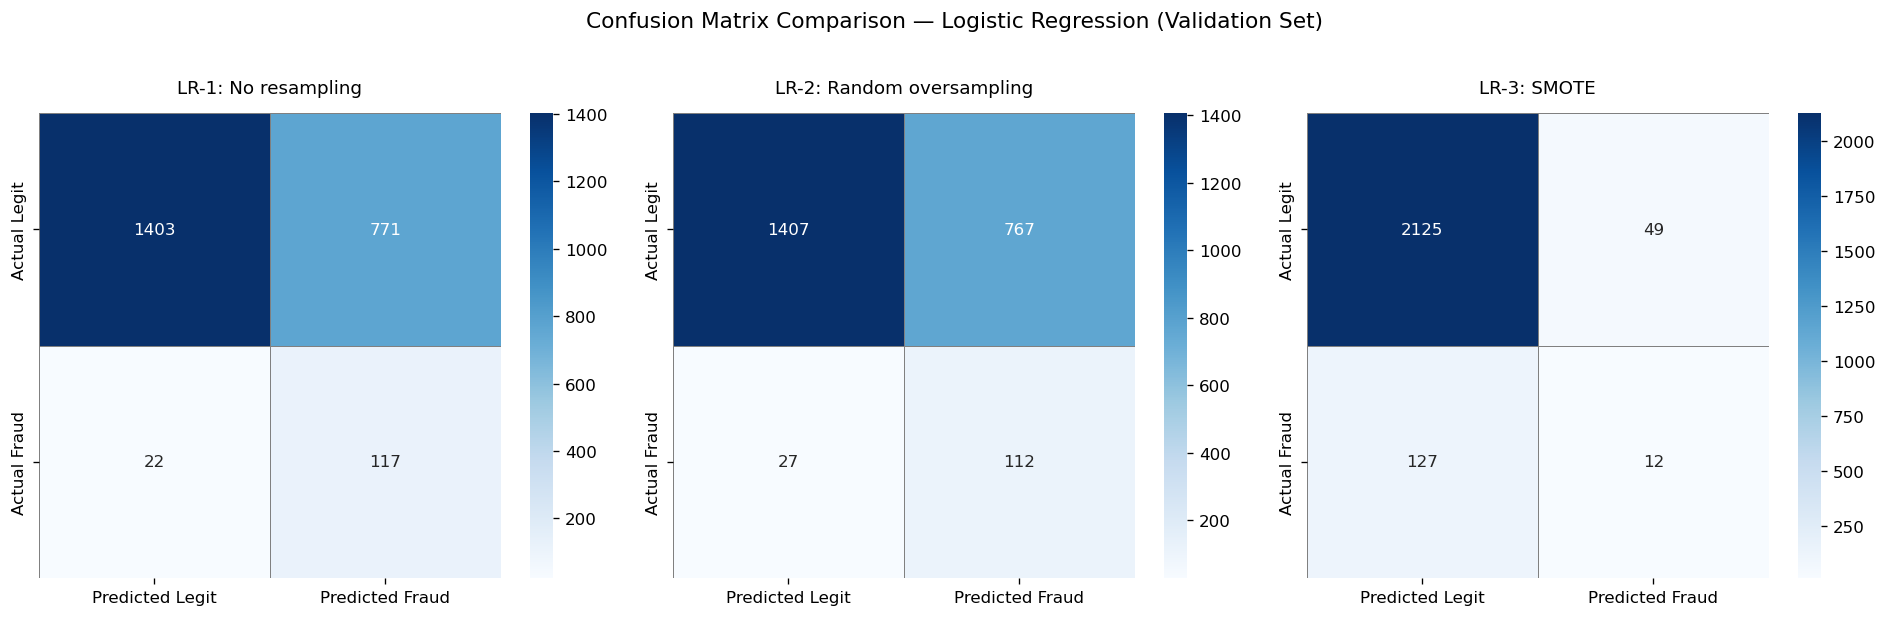

In [47]:
lr1_val_pr_auc   = average_precision_score(y_val, y_val_proba_lr1)
lr1_val_roc_auc  = roc_auc_score(y_val, y_val_proba_lr1)
lr1_val_precision = precision_score(y_val, y_val_pred_lr1, zero_division=0)
lr1_val_recall   = recall_score(y_val, y_val_pred_lr1, zero_division=0)
lr1_val_f1       = f1_score(y_val, y_val_pred_lr1, zero_division=0)
lr1_val_cm       = confusion_matrix(y_val, y_val_pred_lr1)

lr2_val_pr_auc   = average_precision_score(y_val, y_val_proba_lr2)
lr2_val_roc_auc  = roc_auc_score(y_val, y_val_proba_lr2)
lr2_val_precision = precision_score(y_val, y_val_pred_lr2, zero_division=0)
lr2_val_recall   = recall_score(y_val, y_val_pred_lr2, zero_division=0)
lr2_val_f1       = f1_score(y_val, y_val_pred_lr2, zero_division=0)
lr2_val_cm       = confusion_matrix(y_val, y_val_pred_lr2)

lr3_val_pr_auc   = average_precision_score(y_val, y_val_proba_lr3)
lr3_val_roc_auc  = roc_auc_score(y_val, y_val_proba_lr3)
lr3_val_precision = precision_score(y_val, y_val_pred_lr3, zero_division=0)
lr3_val_recall   = recall_score(y_val, y_val_pred_lr3, zero_division=0)
lr3_val_f1       = f1_score(y_val, y_val_pred_lr3, zero_division=0)
lr3_val_cm       = confusion_matrix(y_val, y_val_pred_lr3)

# Summary table
results_lr = pd.DataFrame({
    'Model': ['LR-1 (no resampling)', 'LR-2 (oversampling)', 'LR-3 (SMOTE)'],
    'PR-AUC':    [lr1_val_pr_auc,    lr2_val_pr_auc,    lr3_val_pr_auc],
    'ROC-AUC':   [lr1_val_roc_auc,   lr2_val_roc_auc,   lr3_val_roc_auc],
    'Precision': [lr1_val_precision,  lr2_val_precision,  lr3_val_precision],
    'Recall':    [lr1_val_recall,     lr2_val_recall,     lr3_val_recall],
    'F1':        [lr1_val_f1,         lr2_val_f1,         lr3_val_f1],
}).round(4)

print("\n=== Logistic Regression — Validation Results ===")
print(results_lr.to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

models_lr = [
    (lr1_val_cm, 'LR-1: No resampling'),
    (lr2_val_cm, 'LR-2: Random oversampling'),
    (lr3_val_cm, 'LR-3: SMOTE'),
]

for ax, (cm, title) in zip(axes, models_lr):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Predicted Legit', 'Predicted Fraud'],
                yticklabels=['Actual Legit', 'Actual Fraud'],
                linewidths=0.5, linecolor='gray', ax=ax)
    ax.set_title(title, fontsize=11, pad=12)

plt.suptitle('Confusion Matrix Comparison — Logistic Regression (Validation Set)',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## Precision-Recall Curves for the models

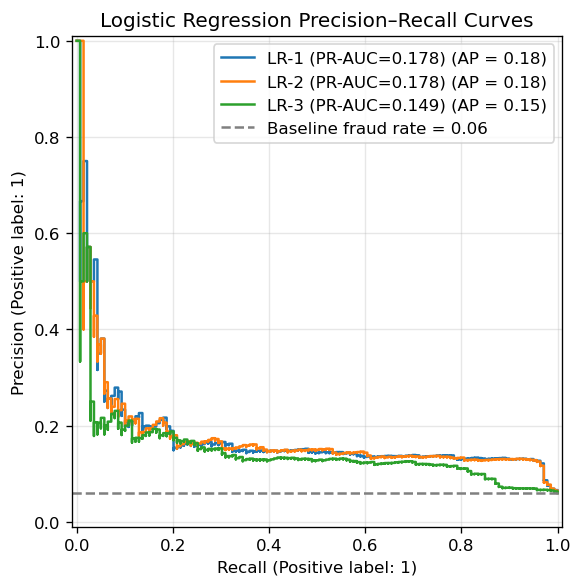

In [49]:
fig, ax = plt.subplots(figsize=(7, 5))

# LR-1
PrecisionRecallDisplay.from_predictions(
    y_val,
    y_val_proba_lr1,
    name=f"LR-1 (PR-AUC={lr1_val_pr_auc:.3f})",
    ax=ax
)

# LR-2
PrecisionRecallDisplay.from_predictions(
    y_val,
    y_val_proba_lr2,
    name=f"LR-2 (PR-AUC={lr2_val_pr_auc:.3f})",
    ax=ax
)

# LR-3
PrecisionRecallDisplay.from_predictions(
    y_val,
    y_val_proba_lr3,
    name=f"LR-3 (PR-AUC={lr3_val_pr_auc:.3f})",
    ax=ax
)

# Baseline fraud rate
fraud_rate = y_val.mean()

ax.axhline(
    fraud_rate,
    color="gray",
    linestyle="--",
    label=f"Baseline fraud rate = {fraud_rate:.2f}"
)

# Formatting
ax.set_title("Logistic Regression Precision–Recall Curves")
ax.grid(alpha=0.3)
ax.legend(loc="upper right")

plt.tight_layout()
plt.show()

## Leakage check

In [51]:
train_idx = set(X_train.index)
val_idx   = set(X_val.index)
test_idx  = set(X_test.index)

print("\nLeakage check")
print(f"Train/Val overlap:  {len(train_idx & val_idx)} samples")
print(f"Train/Test overlap: {len(train_idx & test_idx)} samples")
print(f"Val/Test overlap:   {len(val_idx & test_idx)} samples")
print(f"Total accounted for: {len(train_idx | val_idx | test_idx)} (should be 15420)")


Leakage check
Train/Val overlap:  0 samples
Train/Test overlap: 0 samples
Val/Test overlap:   0 samples
Total accounted for: 15420 (should be 15420)


# Hyperparameter tuning for LR-1

In [226]:
warnings.filterwarnings("ignore")

# Base LR model
lr_base = LogisticRegression(
    class_weight="balanced",
    random_state=42,
    max_iter=2000
)

# Grid for LR-1
lr_param_grid = {
    "C": [0.01, 0.1, 1, 10, 100],
    "penalty": ["l1", "l2"],
    "solver": ["liblinear"]   # supports both l1 and l2
}

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

lr_grid = GridSearchCV(
    estimator=lr_base,
    param_grid=lr_param_grid,
    scoring="average_precision",   # PR-AUC
    cv=cv,
    n_jobs=-1,
    verbose=1
)

lr_grid.fit(X_train, y_train)

print("Best CV PR-AUC:", round(lr_grid.best_score_, 4))
print("Best parameters:", lr_grid.best_params_)

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best CV PR-AUC: 0.1489
Best parameters: {'C': 0.01, 'penalty': 'l1', 'solver': 'liblinear'}


## LR-1 tuned model training

=== LR-1 Tuned Validation Results (threshold=0.5) ===
PR-AUC:   0.1779
ROC-AUC:  0.7974
Precision:0.1270
Recall:   0.9209
F1-score: 0.2232
Confusion matrix:
[[1294  880]
 [  11  128]]


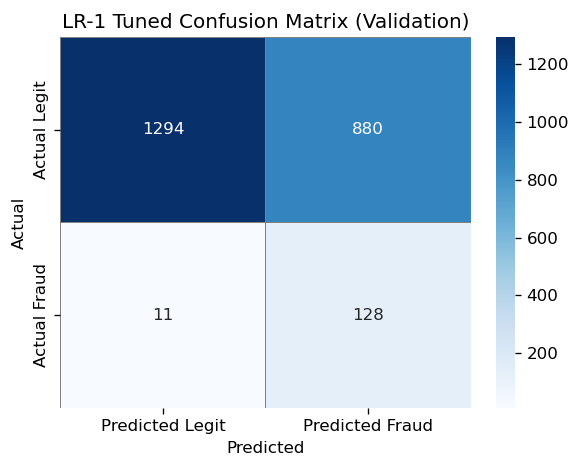

In [228]:
warnings.filterwarnings("ignore")

lr1_tuned = LogisticRegression(
    C=0.01,
    penalty="l1",
    solver="liblinear",
    class_weight="balanced",
    random_state=42,
    max_iter=2000
)

lr1_tuned.fit(X_train, y_train)

# Validation probabilities
y_val_proba_lr1_tuned = lr1_tuned.predict_proba(X_val)[:, 1]

# Default threshold = 0.5
y_val_pred_lr1_tuned = (y_val_proba_lr1_tuned >= 0.5).astype(int)

# Metrics at threshold 0.5
lr1_tuned_val_pr_auc = average_precision_score(y_val, y_val_proba_lr1_tuned)
lr1_tuned_val_roc_auc = roc_auc_score(y_val, y_val_proba_lr1_tuned)
lr1_tuned_val_precision = precision_score(y_val, y_val_pred_lr1_tuned, zero_division=0)
lr1_tuned_val_recall = recall_score(y_val, y_val_pred_lr1_tuned, zero_division=0)
lr1_tuned_val_f1 = f1_score(y_val, y_val_pred_lr1_tuned, zero_division=0)
lr1_tuned_val_cm = confusion_matrix(y_val, y_val_pred_lr1_tuned)

print("=== LR-1 Tuned Validation Results (threshold=0.5) ===")
print(f"PR-AUC:   {lr1_tuned_val_pr_auc:.4f}")
print(f"ROC-AUC:  {lr1_tuned_val_roc_auc:.4f}")
print(f"Precision:{lr1_tuned_val_precision:.4f}")
print(f"Recall:   {lr1_tuned_val_recall:.4f}")
print(f"F1-score: {lr1_tuned_val_f1:.4f}")
print("Confusion matrix:")
print(lr1_tuned_val_cm)

fig, ax = plt.subplots(figsize=(5, 4))

sns.heatmap(
    lr1_tuned_val_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Predicted Legit", "Predicted Fraud"],
    yticklabels=["Actual Legit", "Actual Fraud"],
    linewidths=0.5,
    linecolor="gray",
    ax=ax
)

ax.set_title("LR-1 Tuned Confusion Matrix (Validation)")
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()

## Threshold Sweep

In [230]:
# Evaluate multiple classification thresholds for the tuned Logistic Regression model
thresholds = np.arange(0.05, 0.95, 0.05)

lr_thresh_rows = []

# Convert predicted probabilities into class predictions using different thresholds
for t in thresholds:
    preds = (y_val_proba_lr1_tuned >= t).astype(int)
    lr_thresh_rows.append({
        "threshold": round(t, 2),
        "precision": round(precision_score(y_val, preds, zero_division=0), 3),
        "recall": round(recall_score(y_val, preds, zero_division=0), 3),
        "f1": round(f1_score(y_val, preds, zero_division=0), 3),
    })

# Store threshold evaluation metrics into a dataframe
lr_thresh_df = pd.DataFrame(lr_thresh_rows)

# Select the threshold with the highest F1-score
best_lr_idx = lr_thresh_df["f1"].idxmax()
best_lr_threshold = lr_thresh_df.loc[best_lr_idx, "threshold"]

print("=== LR-1 Threshold Sweep ===")
print(lr_thresh_df.to_string(index=False))
print(f"\nBest threshold: {best_lr_threshold:.2f}")

=== LR-1 Threshold Sweep ===
 threshold  precision  recall    f1
      0.05      0.062   1.000 0.118
      0.10      0.063   1.000 0.118
      0.15      0.066   1.000 0.124
      0.20      0.095   0.978 0.172
      0.25      0.119   0.971 0.212
      0.30      0.127   0.964 0.225
      0.35      0.127   0.935 0.224
      0.40      0.127   0.928 0.223
      0.45      0.127   0.928 0.223
      0.50      0.127   0.921 0.223
      0.55      0.127   0.849 0.222
      0.60      0.141   0.597 0.228
      0.65      0.149   0.496 0.229
      0.70      0.168   0.273 0.208
      0.75      0.181   0.137 0.156
      0.80      0.455   0.036 0.067
      0.85      1.000   0.007 0.014
      0.90      0.000   0.000 0.000

Best threshold: 0.65


## LR-1 Tuned — Threshold vs Metrics

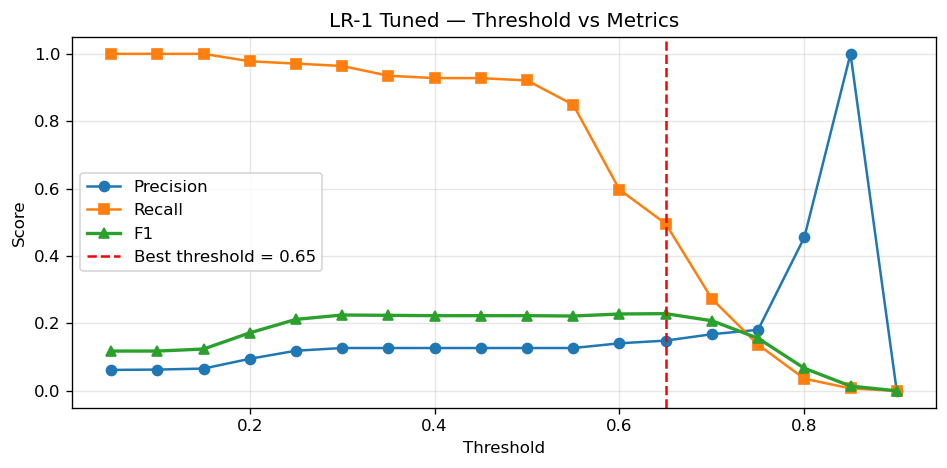

In [232]:
# Plot precision, recall, and F1-score across different classification thresholds
fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(lr_thresh_df["threshold"], lr_thresh_df["precision"], marker="o", label="Precision")
ax.plot(lr_thresh_df["threshold"], lr_thresh_df["recall"], marker="s", label="Recall")
ax.plot(lr_thresh_df["threshold"], lr_thresh_df["f1"], marker="^", linewidth=2, label="F1")

# Highlight the threshold that achieved the best F1-score
ax.axvline(
    best_lr_threshold,
    color="red",
    linestyle="--",
    label=f"Best threshold = {best_lr_threshold:.2f}"
)

ax.set_title("LR-1 Tuned — Threshold vs Metrics")
ax.set_xlabel("Threshold")
ax.set_ylabel("Score")
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

## LR-1 Final Validation Results (tuned threshold)

=== LR-1 Final Validation Results (tuned threshold) ===
PR-AUC:    0.1779
Threshold: 0.65
Precision: 0.1490
Recall:    0.4964
F1-score:  0.2292
Confusion matrix:
[[1780  394]
 [  70   69]]


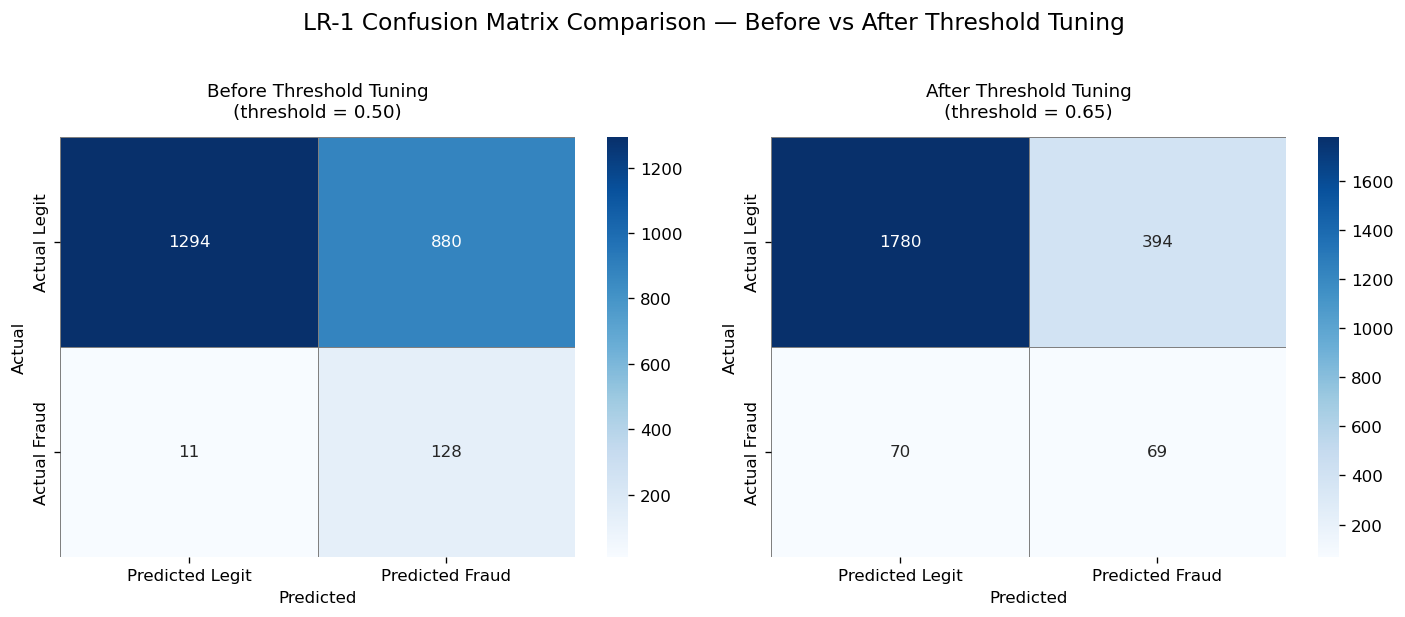

In [234]:
# Generate final class predictions using the selected optimal threshold
y_val_pred_lr1_final = (y_val_proba_lr1_tuned >= best_lr_threshold).astype(int)

# Calculate final validation metrics after threshold tuning
lr1_final_pr_auc   = average_precision_score(y_val, y_val_proba_lr1_tuned)
lr1_final_precision = precision_score(y_val, y_val_pred_lr1_final, zero_division=0)
lr1_final_recall = recall_score(y_val, y_val_pred_lr1_final, zero_division=0)
lr1_final_f1 = f1_score(y_val, y_val_pred_lr1_final, zero_division=0)
lr1_final_cm = confusion_matrix(y_val, y_val_pred_lr1_final)

print("=== LR-1 Final Validation Results (tuned threshold) ===")
print(f"PR-AUC:    {lr1_final_pr_auc:.4f}")
print(f"Threshold: {best_lr_threshold:.2f}")
print(f"Precision: {lr1_final_precision:.4f}")
print(f"Recall:    {lr1_final_recall:.4f}")
print(f"F1-score:  {lr1_final_f1:.4f}")
print("Confusion matrix:")
print(lr1_final_cm)

# Compare confusion matrices before and after threshold tuning
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# BEFORE threshold tuning (0.5)
sns.heatmap(
    lr1_tuned_val_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Predicted Legit", "Predicted Fraud"],
    yticklabels=["Actual Legit", "Actual Fraud"],
    linewidths=0.5,
    linecolor="gray",
    ax=axes[0]
)

axes[0].set_title(
    "Before Threshold Tuning\n(threshold = 0.50)",
    fontsize=11,
    pad=12
)

axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")


# AFTER threshold tuning
sns.heatmap(
    lr1_final_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Predicted Legit", "Predicted Fraud"],
    yticklabels=["Actual Legit", "Actual Fraud"],
    linewidths=0.5,
    linecolor="gray",
    ax=axes[1]
)

axes[1].set_title(
    f"After Threshold Tuning\n(threshold = {best_lr_threshold:.2f})",
    fontsize=11,
    pad=12
)

axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

# Main title comparing both confusion matrices
plt.suptitle(
    "LR-1 Confusion Matrix Comparison — Before vs After Threshold Tuning",
    fontsize=14,
    y=1.02
)

plt.tight_layout()
plt.show()

---
## 12. Random Forest

Random Forest is a powerful ensemble method that constructs multiple decision trees independently, utilizing bootstrap sampling and random subsets of features. It then combines their predictions through a majority vote. Unlike Logistic Regression, Random Forest has the ability to capture non-linear relationships between features and tends to be more resilient when dealing with noisy or mixed-type tabular data. In this context, it serves as a more sophisticated baseline to evaluate whether adding complexity to the model enhances fraud detection.

RF-1, RF-2 and RF-3 are performed; RF-1 without resampling, RF-2 with random oversampling and RF-3 with SMOTE. The initial validation result indicated that all the three models yielded relatively high ROC-AUC score of about 0.81 to 0.82, which means that the models were relatively effective in ranking the fraud and non-fraud claims. Nevertheless, the recall scores were very low with default threshold of 0.5. RF-1 yielded a precision of over 0.83 and recall of 0.036, implying that it successfully classified less than 4% of fraud cases. The confusion matrices also verified the same result since the models were too conservative and did not classify most of the fraud cases.

The above analysis made clear that the issue was not with the model capacity, but with the threshold. The ranking information was available in the predicted probabilities from PR-AUC values.

RF-1 and RF-2 models were chosen for hyperparameter tuning using coarse random search – 15 iterations of `RandomizedSearchCV` with 3-fold stratified cross-validation scoring based on PR-AUC. Further, threshold optimisation was performed by sweeping thresholds from 0.05 to 0.80 on the validation set. The optimum threshold for RF-1 was 0.30, resulting in an increase in recall from 0.101 to 0.518. For RF-2, the optimum threshold was 0.15, leading to a recall increase from 0.065 to about 0.60. Therefore, threshold optimisation proved to be significantly more effective than hyperparameter tuning in this case. RF-2 Tuned with threshold 0.15 was considered the best Random Forest model due to its best performance on the trade-off between the ability to detect fraud and accuracy.

The feature importance analysis indicated that the key features were `fault`, `age`, `basepolicy`, `policytype`, `weekofmonth`, `driverrating`, `vehiclecategory`, and previous claims history. These variables correspond to the common indicators of risks of fraud in claims for automobile insurance.

# Random Forest

In [63]:
def build_rf_model(class_weight=None):
    model = RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        min_samples_split=2,
        min_samples_leaf=1,
        max_features="sqrt",
        class_weight=class_weight,
        random_state=42,
        n_jobs=-1
    )

    return model

## Fitting the 3 models

In [65]:
# RF 1: No resampling.
X_train_rf1, y_train_rf1 = no_resampling(X_train, y_train)
rf1 = build_rf_model(class_weight="balanced") # class_weight to balanced.
rf1.fit(X_train_rf1, y_train_rf1)

# RF 2: Random oversampling
X_train_rf2, y_train_rf2 = random_oversampling(X_train, y_train)
rf2 = build_rf_model(class_weight=None)
rf2.fit(X_train_rf2, y_train_rf2)

# RF 3: SMOTE
X_train_rf3, y_train_rf3 = smote_resampling(X_train, y_train)
rf3 = build_rf_model(class_weight=None)
rf3.fit(X_train_rf3, y_train_rf3)

print("All 3 Random Forest models fitted.")

All 3 Random Forest models fitted.


## Validation predictions + metrics

In [67]:
# RF 1: No resampling.
y_val_proba_rf1 = rf1.predict_proba(X_val)[:, 1]
y_val_pred_rf1 = (y_val_proba_rf1 >= 0.5).astype(int)

rf1_val_pr_auc = average_precision_score(y_val, y_val_proba_rf1)
rf1_val_roc_auc = roc_auc_score(y_val, y_val_proba_rf1)
rf1_val_precision = precision_score(y_val, y_val_pred_rf1, zero_division=0)
rf1_val_recall = recall_score(y_val, y_val_pred_rf1, zero_division=0)
rf1_val_f1 = f1_score(y_val, y_val_pred_rf1, zero_division=0)
rf1_val_cm = confusion_matrix(y_val, y_val_pred_rf1)

# RF 2: Random oversampling
y_val_proba_rf2 = rf2.predict_proba(X_val)[:, 1]
y_val_pred_rf2 = (y_val_proba_rf2 >= 0.5).astype(int)

rf2_val_pr_auc = average_precision_score(y_val, y_val_proba_rf2)
rf2_val_roc_auc = roc_auc_score(y_val, y_val_proba_rf2)
rf2_val_precision = precision_score(y_val, y_val_pred_rf2, zero_division=0)
rf2_val_recall = recall_score(y_val, y_val_pred_rf2, zero_division=0)
rf2_val_f1 = f1_score(y_val, y_val_pred_rf2, zero_division=0)
rf2_val_cm = confusion_matrix(y_val, y_val_pred_rf2)

# RF 3: SMOTE
y_val_proba_rf3 = rf3.predict_proba(X_val)[:, 1]
y_val_pred_rf3 = (y_val_proba_rf3 >= 0.5).astype(int)

rf3_val_pr_auc = average_precision_score(y_val, y_val_proba_rf3)
rf3_val_roc_auc = roc_auc_score(y_val, y_val_proba_rf3)
rf3_val_precision = precision_score(y_val, y_val_pred_rf3, zero_division=0)
rf3_val_recall = recall_score(y_val, y_val_pred_rf3, zero_division=0)
rf3_val_f1 = f1_score(y_val, y_val_pred_rf3, zero_division=0)
rf3_val_cm = confusion_matrix(y_val, y_val_pred_rf3)

## Metrics Summary comparison table

In [69]:
results_rf = pd.DataFrame({
    'Model': ['RF 1 (no resampling)', 'RF 2 (oversampling)', 'RF 3 (SMOTE)'],
    'PR-AUC': [rf1_val_pr_auc,    rf2_val_pr_auc,    rf3_val_pr_auc],
    'ROC-AUC':   [rf1_val_roc_auc,   rf2_val_roc_auc,   rf3_val_roc_auc],
    'Precision': [rf1_val_precision,  rf2_val_precision,  rf3_val_precision],
    'Recall':    [rf1_val_recall,     rf2_val_recall,     rf3_val_recall],
    'F1':        [rf1_val_f1,         rf2_val_f1,         rf3_val_f1],
}).round(4)

print("\n=== Random Forest — Validation Results ===")
print(results_rf.to_string(index=False))


=== Random Forest — Validation Results ===
               Model  PR-AUC  ROC-AUC  Precision  Recall     F1
RF 1 (no resampling)  0.2361   0.8239     0.7500  0.0216 0.0420
 RF 2 (oversampling)  0.2369   0.8238     0.6923  0.0647 0.1184
        RF 3 (SMOTE)  0.2051   0.8088     0.5556  0.0360 0.0676


## Confusion Matrix (Validation) Comparison

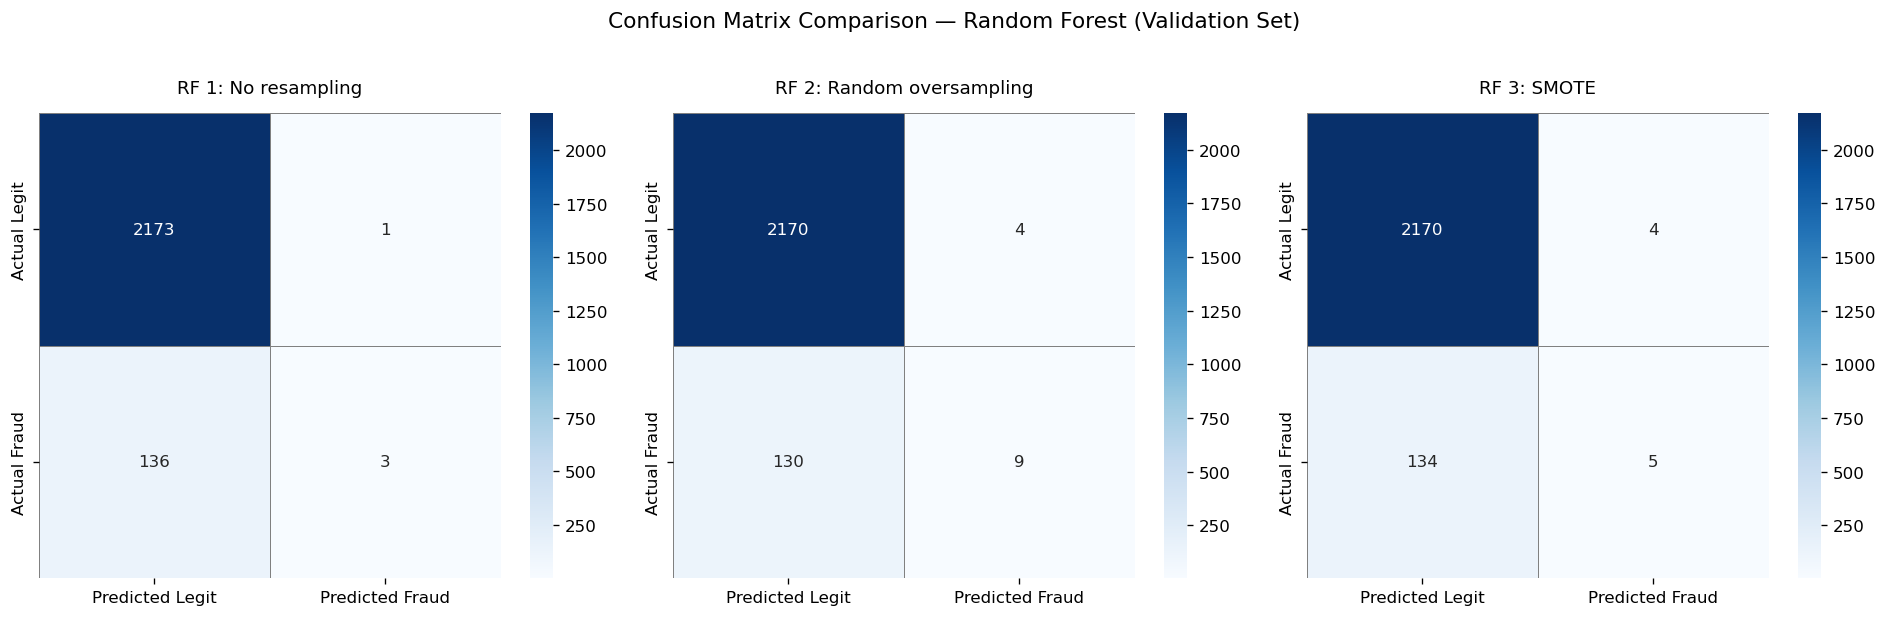

In [236]:
# Compare confusion matrices across the three Random Forest approaches
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

models_lr = [
    (rf1_val_cm, 'RF 1: No resampling'),
    (rf2_val_cm, 'RF 2: Random oversampling'),
    (rf3_val_cm, 'RF 3: SMOTE'),
]

for ax, (cm, title) in zip(axes, models_lr):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Predicted Legit', 'Predicted Fraud'],
                yticklabels=['Actual Legit', 'Actual Fraud'],
                linewidths=0.5, linecolor='gray', ax=ax)
    ax.set_title(title, fontsize=11, pad=12)

plt.suptitle('Confusion Matrix Comparison — Random Forest (Validation Set)',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## Precision-Recall Curve Comparison

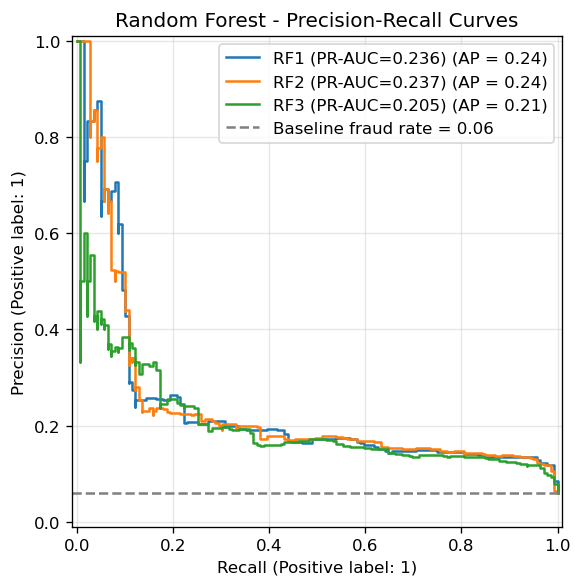

In [238]:
# Plot Precision-Recall curves for all Random Forest models
fig, ax = plt.subplots(figsize=(7, 5))

PrecisionRecallDisplay.from_predictions(
    y_val, y_val_proba_rf1,
    name=f"RF1 (PR-AUC={rf1_val_pr_auc:.3f})",
    ax=ax
)

PrecisionRecallDisplay.from_predictions(
    y_val, y_val_proba_rf2,
    name=f"RF2 (PR-AUC={rf2_val_pr_auc:.3f})",
    ax=ax
)

PrecisionRecallDisplay.from_predictions(
    y_val, y_val_proba_rf3,
    name=f"RF3 (PR-AUC={rf3_val_pr_auc:.3f})",
    ax=ax
)

# Add baseline fraud rate for comparison
fraud_rate = y_val.mean()
ax.axhline(fraud_rate, color="gray", linestyle="--",
           label=f"Baseline fraud rate = {fraud_rate:.2f}")

ax.set_title("Random Forest - Precision-Recall Curves")
ax.grid(alpha=0.3)
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

## Random Forest Hyperparameter Tuning -- RF 1 & RF 2


In [76]:
# Parameter search space
rf_param_dist = {
    "n_estimators": [200, 400, 600],
    "max_depth": [None, 5, 10, 15],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"]
}

base_rf = RandomForestClassifier(
    class_weight="balanced",
    random_state=42,
    n_jobs=1  # changed from -1
)

# Randomized search
rf1_random_search = RandomizedSearchCV(
    estimator=base_rf,
    param_distributions=rf_param_dist,
    n_iter=15,
    scoring="average_precision",
    cv=cv,
    random_state=42,
    n_jobs=1,  # changed from -1
    verbose=1
)

# Fit search
rf1_random_search.fit(X_train, y_train)

# Results
rf1_best_params = rf1_random_search.best_params_
rf1_best_score = rf1_random_search.best_score_

print("\n=== RF-1 Coarse Search Results ===")
print(f"Best CV PR-AUC: {rf1_best_score:.4f}")
print("Best Parameters:")
print(rf1_best_params)

rf2_random_search = RandomizedSearchCV(
    RandomForestClassifier(class_weight=None, random_state=42, n_jobs=-1),
    rf_param_dist,
    n_iter=15,
    scoring="average_precision",
    cv=cv,
    random_state=42,
    n_jobs=1,
    verbose=1
)
rf2_random_search.fit(X_train_rf2, y_train_rf2)

print("\n=== RF-2 Coarse Search Results ===")
print(f"Best CV PR-AUC: {rf2_random_search.best_score_:.4f}")
print(f"Best params: {rf2_random_search.best_params_}")

Fitting 3 folds for each of 15 candidates, totalling 45 fits

=== RF-1 Coarse Search Results ===
Best CV PR-AUC: 0.1856
Best Parameters:
{'n_estimators': 200, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': None}
Fitting 3 folds for each of 15 candidates, totalling 45 fits

=== RF-2 Coarse Search Results ===
Best CV PR-AUC: 1.0000
Best params: {'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': None}


# Build tuned RF model


In [78]:
# RF-1 Tuned
rf1_tuned = RandomForestClassifier(
    n_estimators=rf1_random_search.best_params_["n_estimators"],
    max_depth=rf1_random_search.best_params_["max_depth"],
    min_samples_split=rf1_random_search.best_params_["min_samples_split"],
    min_samples_leaf=rf1_random_search.best_params_["min_samples_leaf"],
    max_features=rf1_random_search.best_params_["max_features"],
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)
rf1_tuned.fit(X_train, y_train)

y_val_proba_rf1_tuned = rf1_tuned.predict_proba(X_val)[:, 1]
y_val_pred_rf1_tuned = (y_val_proba_rf1_tuned >= 0.5).astype(int)

rf1_tuned_val_prauc = average_precision_score(y_val, y_val_proba_rf1_tuned)
rf1_tuned_val_rocauc = roc_auc_score(y_val, y_val_proba_rf1_tuned)
rf1_tuned_val_precision = precision_score(y_val, y_val_pred_rf1_tuned, zero_division=0)
rf1_tuned_val_recall = recall_score(y_val, y_val_pred_rf1_tuned, zero_division=0)
rf1_tuned_val_f1 = f1_score(y_val, y_val_pred_rf1_tuned, zero_division=0)
rf1_tuned_val_cm = confusion_matrix(y_val, y_val_pred_rf1_tuned)



# RF-2 Tuned
rf2_tuned = RandomForestClassifier(
    n_estimators=rf2_random_search.best_params_["n_estimators"],
    max_depth=rf2_random_search.best_params_["max_depth"],
    min_samples_split=rf2_random_search.best_params_["min_samples_split"],
    min_samples_leaf=rf2_random_search.best_params_["min_samples_leaf"],
    max_features=rf2_random_search.best_params_["max_features"],
    class_weight=None,
    random_state=42,
    n_jobs=-1
)
rf2_tuned.fit(X_train_rf2, y_train_rf2)

y_val_proba_rf2_tuned = rf2_tuned.predict_proba(X_val)[:, 1]
y_val_pred_rf2_tuned = (y_val_proba_rf2_tuned >= 0.5).astype(int)

rf2_tuned_val_prauc = average_precision_score(y_val, y_val_proba_rf2_tuned)
rf2_tuned_val_rocauc = roc_auc_score(y_val, y_val_proba_rf2_tuned)
rf2_tuned_val_precision = precision_score(y_val, y_val_pred_rf2_tuned, zero_division=0)
rf2_tuned_val_recall = recall_score(y_val, y_val_pred_rf2_tuned, zero_division=0)
rf2_tuned_val_f1 = f1_score(y_val, y_val_pred_rf2_tuned, zero_division=0)
rf2_tuned_val_cm = confusion_matrix(y_val, y_val_pred_rf2_tuned)



## Summary metrics & confusion matrics of tuned models

=== Random Forest — Default vs Tuned (Validation) ===
         Model  PR-AUC  ROC-AUC  Precision  Recall     F1
RF-1 (default)  0.2361   0.8239     0.7500  0.0216 0.0420
    RF-1 Tuned  0.2294   0.8305     0.5161  0.1151 0.1882
RF-2 (default)  0.2369   0.8238     0.6923  0.0647 0.1184
    RF-2 Tuned  0.2277   0.8198     0.6667  0.0576 0.1060


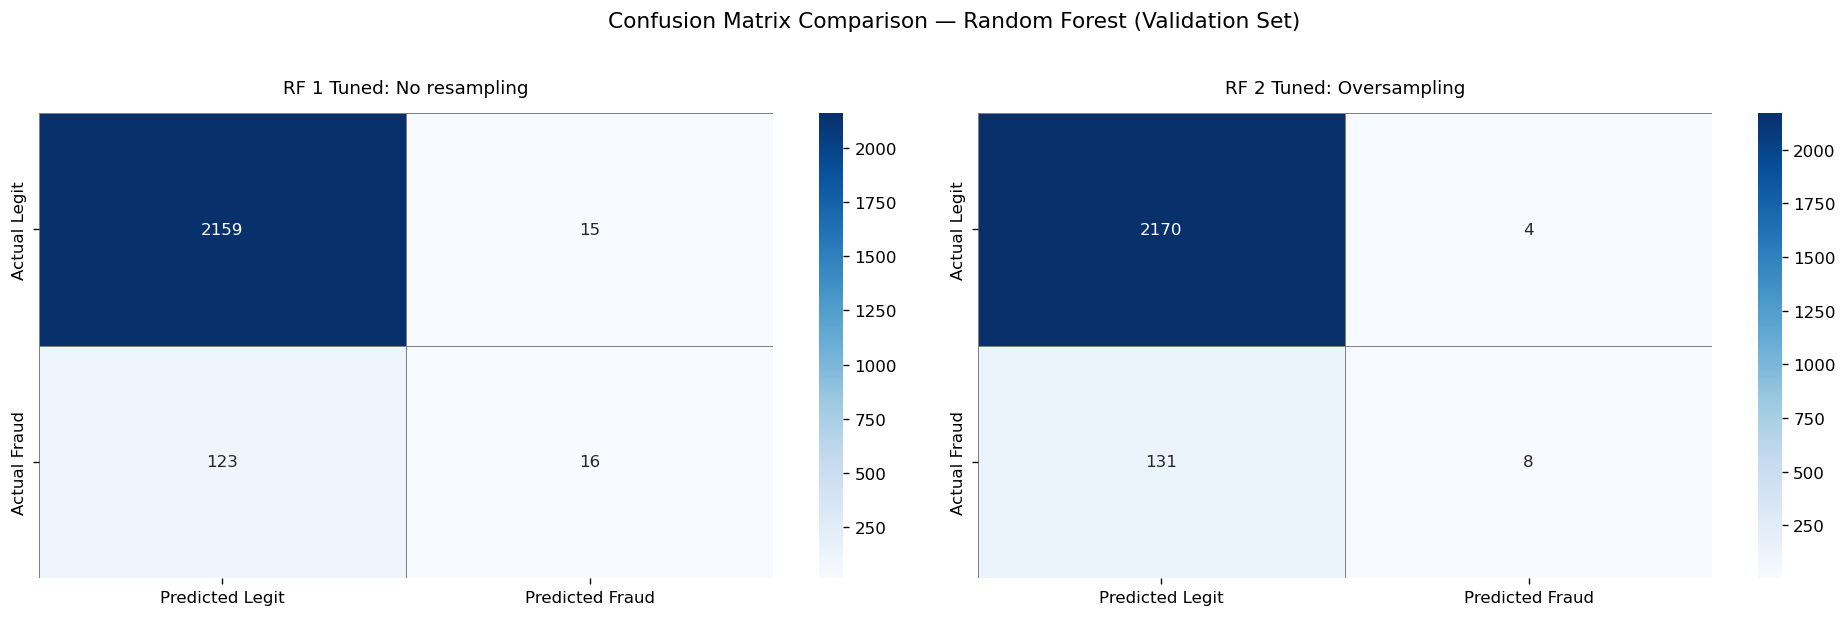

In [240]:
# Compare validation performance before and after hyperparameter tuning
results_rf_tuned_vs_default = pd.DataFrame({
    'Model':     ['RF-1 (default)', 'RF-1 Tuned', 'RF-2 (default)',  'RF-2 Tuned'],
    'PR-AUC':    [rf1_val_pr_auc,        rf1_tuned_val_prauc, rf2_val_pr_auc,             rf2_tuned_val_prauc],
    'ROC-AUC':   [rf1_val_roc_auc,     rf1_tuned_val_rocauc,  rf2_val_roc_auc,           rf2_tuned_val_rocauc],
    'Precision': [rf1_val_precision,   rf1_tuned_val_precision,   rf2_val_precision,       rf2_tuned_val_precision],
    'Recall':    [rf1_val_recall,       rf1_tuned_val_recall,   rf2_val_recall,            rf2_tuned_val_recall],
    'F1':        [rf1_val_f1,          rf1_tuned_val_f1,      rf2_val_f1,                  rf2_tuned_val_f1],
}).round(4)

print("=== Random Forest — Default vs Tuned (Validation) ===")
print(results_rf_tuned_vs_default.to_string(index=False))


# Compare confusion matrices for the tuned Random Forest models
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

models_lr = [
    (rf1_tuned_val_cm, 'RF 1 Tuned: No resampling'),
    (rf2_tuned_val_cm, 'RF 2 Tuned: Oversampling'),
]

for ax, (cm, title) in zip(axes, models_lr):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Predicted Legit', 'Predicted Fraud'],
                yticklabels=['Actual Legit', 'Actual Fraud'],
                linewidths=0.5, linecolor='gray', ax=ax)
    ax.set_title(title, fontsize=11, pad=12)

plt.suptitle('Confusion Matrix Comparison — Random Forest (Validation Set)',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## Threshold tuning

In [242]:
# Threshold tuning for the tuned RF-1 model
thresholds = np.arange(0.05, 0.85, 0.05)

rf1_thresh_rows = []
for t in thresholds:
    preds = (y_val_proba_rf1_tuned >= t).astype(int)
    rf1_thresh_rows.append({
        "threshold": round(t, 2),
        "precision": round(precision_score(y_val, preds, zero_division=0), 3),
        "recall":    round(recall_score(y_val, preds, zero_division=0), 3),
        "f1":        round(f1_score(y_val, preds, zero_division=0), 3),
    })

rf1_thresh_df = pd.DataFrame(rf1_thresh_rows)
best_rf1_idx  = rf1_thresh_df["f1"].idxmax()
best_t_rf1    = rf1_thresh_df.loc[best_rf1_idx, "threshold"]

print("=== RF-1 Tuned Threshold Sweep ===")
print(rf1_thresh_df.to_string(index=False))
print(f"\nBest threshold: {best_t_rf1:.2f}")



# Threshold tuning for the tuned RF-2 model

rf2_thresh_rows = []
for t in thresholds:
    preds = (y_val_proba_rf2_tuned >= t).astype(int)
    rf2_thresh_rows.append({
        "threshold": round(t, 2),
        "precision": round(precision_score(y_val, preds, zero_division=0), 3),
        "recall":    round(recall_score(y_val, preds, zero_division=0), 3),
        "f1":        round(f1_score(y_val, preds, zero_division=0), 3),
    })

rf2_thresh_df = pd.DataFrame(rf2_thresh_rows)
best_rf2_idx  = rf2_thresh_df["f1"].idxmax()
best_t_rf2    = rf2_thresh_df.loc[best_rf2_idx, "threshold"]

print("=== RF-2 Tuned Threshold Sweep ===")
print(rf2_thresh_df.to_string(index=False))
print(f"\nBest threshold: {best_t_rf2:.2f}")


=== RF-1 Tuned Threshold Sweep ===
 threshold  precision  recall    f1
      0.05      0.094   0.993 0.172
      0.10      0.123   0.986 0.219
      0.15      0.135   0.964 0.236
      0.20      0.141   0.835 0.242
      0.25      0.163   0.698 0.264
      0.30      0.181   0.504 0.267
      0.35      0.208   0.331 0.256
      0.40      0.225   0.194 0.208
      0.45      0.281   0.115 0.163
      0.50      0.516   0.115 0.188
      0.55      0.500   0.065 0.115
      0.60      0.583   0.050 0.093
      0.65      0.750   0.043 0.082
      0.70      0.333   0.007 0.014
      0.75      1.000   0.007 0.014
      0.80      1.000   0.007 0.014

Best threshold: 0.30
=== RF-2 Tuned Threshold Sweep ===
 threshold  precision  recall    f1
      0.05      0.120   0.993 0.213
      0.10      0.147   0.849 0.251
      0.15      0.159   0.576 0.249
      0.20      0.167   0.331 0.222
      0.25      0.222   0.230 0.226
      0.30      0.270   0.144 0.188
      0.35      0.424   0.101 0.163
      0.

## RF 1 & RF 2 Tuned — Threshold vs Metrics

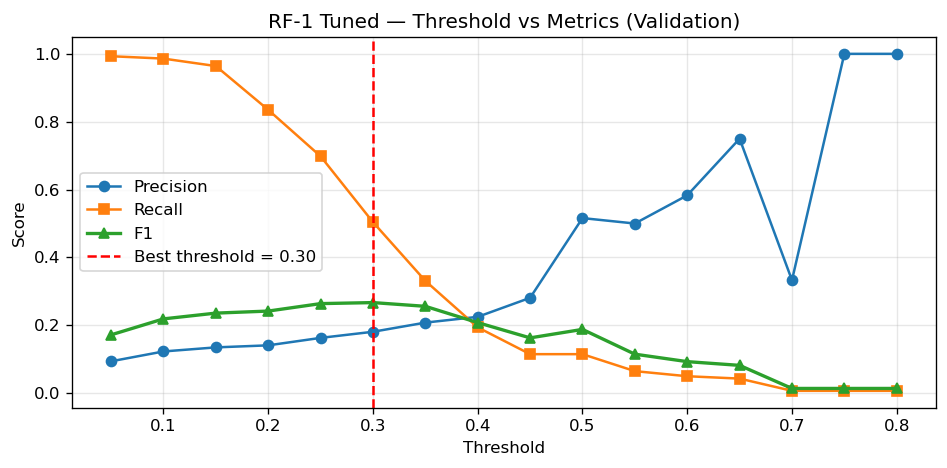

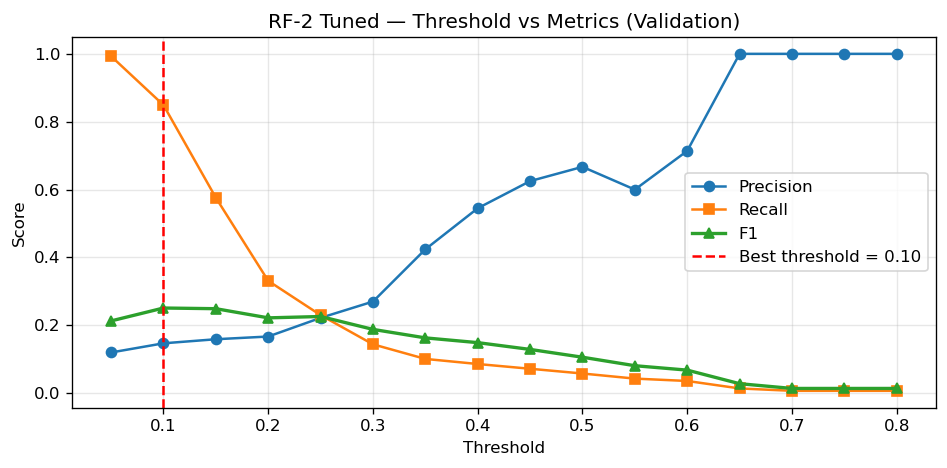

In [244]:
# Plot precision, recall, and F1-score across thresholds for RF-1 Tuned
fig, ax = plt.subplots(figsize=(8, 4))
(ax.plot
 (rf1_thresh_df["threshold"],
  rf1_thresh_df["precision"],
  marker="o",
  label="Precision"))

ax.plot(
    rf1_thresh_df["threshold"],
    rf1_thresh_df["recall"], marker="s", label="Recall")
ax.plot(rf1_thresh_df["threshold"], rf1_thresh_df["f1"],        marker="^", linewidth=2, label="F1")

# Highlight the threshold with the best F1-score
ax.axvline(best_t_rf1, color="red", linestyle="--", label=f"Best threshold = {best_t_rf1:.2f}")

ax.set_title("RF-1 Tuned — Threshold vs Metrics (Validation)")
ax.set_xlabel("Threshold")
ax.set_ylabel("Score")
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

# Plot precision, recall, and F1-score across thresholds for RF-2 Tuned
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(rf2_thresh_df["threshold"], rf2_thresh_df["precision"], marker="o", label="Precision")
ax.plot(rf2_thresh_df["threshold"], rf2_thresh_df["recall"],    marker="s", label="Recall")
ax.plot(rf2_thresh_df["threshold"], rf2_thresh_df["f1"],        marker="^", linewidth=2, label="F1")

# Highlight the threshold with the best F1-score
ax.axvline(best_t_rf2, color="red", linestyle="--", label=f"Best threshold = {best_t_rf2:.2f}")

ax.set_title("RF-2 Tuned — Threshold vs Metrics (Validation)")
ax.set_xlabel("Threshold")
ax.set_ylabel("Score")
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()




## recompute metrics for new threshold


In [246]:
# Generate final predictions for RF-1 Tuned using the selected optimal threshold
y_val_pred_rf1_best = (y_val_proba_rf1_tuned >= best_t_rf1).astype(int)

# Calculate final validation metrics for RF-1 after threshold tuning
rf1_best_prauc     = average_precision_score(y_val, y_val_proba_rf1_tuned)
rf1_best_precision = precision_score(y_val, y_val_pred_rf1_best, zero_division=0)
rf1_best_recall    = recall_score(y_val, y_val_pred_rf1_best, zero_division=0)
rf1_best_f1        = f1_score(y_val, y_val_pred_rf1_best, zero_division=0)
rf1_best_cm        = confusion_matrix(y_val, y_val_pred_rf1_best)

# Generate final predictions for RF-2 Tuned using the selected optimal threshold
best_t_rf2 = 0.10
y_val_pred_rf2_best = (y_val_proba_rf2_tuned >= best_t_rf2).astype(int)

# Calculate final validation metrics for RF-2 after threshold tuning
rf2_best_prauc     = average_precision_score(y_val, y_val_proba_rf2_tuned)
rf2_best_precision = precision_score(y_val, y_val_pred_rf2_best, zero_division=0)
rf2_best_recall    = recall_score(y_val, y_val_pred_rf2_best, zero_division=0)
rf2_best_f1        = f1_score(y_val, y_val_pred_rf2_best, zero_division=0)
rf2_best_cm        = confusion_matrix(y_val, y_val_pred_rf2_best)


## metrics summary table

In [88]:
results_rf_best_thresh = pd.DataFrame({
    'Model':     ['RF-1 Tuned (best thresh)', 'RF-1 Tuned (0.5)', 'RF-2 Tuned (best thresh)', 'RF-2 Tuned (0.5)'],
    'Threshold': [best_t_rf1,            0.5,               best_t_rf2,            0.5],
    'PR-AUC':    [rf1_best_prauc,         rf1_tuned_val_prauc,  rf2_best_prauc,         rf2_tuned_val_prauc],
    'Precision': [rf1_best_precision,     rf1_tuned_val_precision, rf2_best_precision,     rf2_tuned_val_precision],
    'Recall':    [rf1_best_recall,        rf1_tuned_val_recall, rf2_best_recall,        rf2_tuned_val_recall],
    'F1':        [rf1_best_f1,            rf1_tuned_val_f1,     rf2_best_f1,            rf2_tuned_val_f1],
}).round(4)

print("=== RF Tuned — Best Threshold vs Default (0.5) ===")
print(results_rf_best_thresh.to_string(index=False))

=== RF Tuned — Best Threshold vs Default (0.5) ===
                   Model  Threshold  PR-AUC  Precision  Recall     F1
RF-1 Tuned (best thresh)        0.3  0.2294     0.1813  0.5036 0.2667
        RF-1 Tuned (0.5)        0.5  0.2294     0.5161  0.1151 0.1882
RF-2 Tuned (best thresh)        0.1  0.2277     0.1469  0.8489 0.2505
        RF-2 Tuned (0.5)        0.5  0.2277     0.6667  0.0576 0.1060


## Condusion Matrix - new vs old threshold

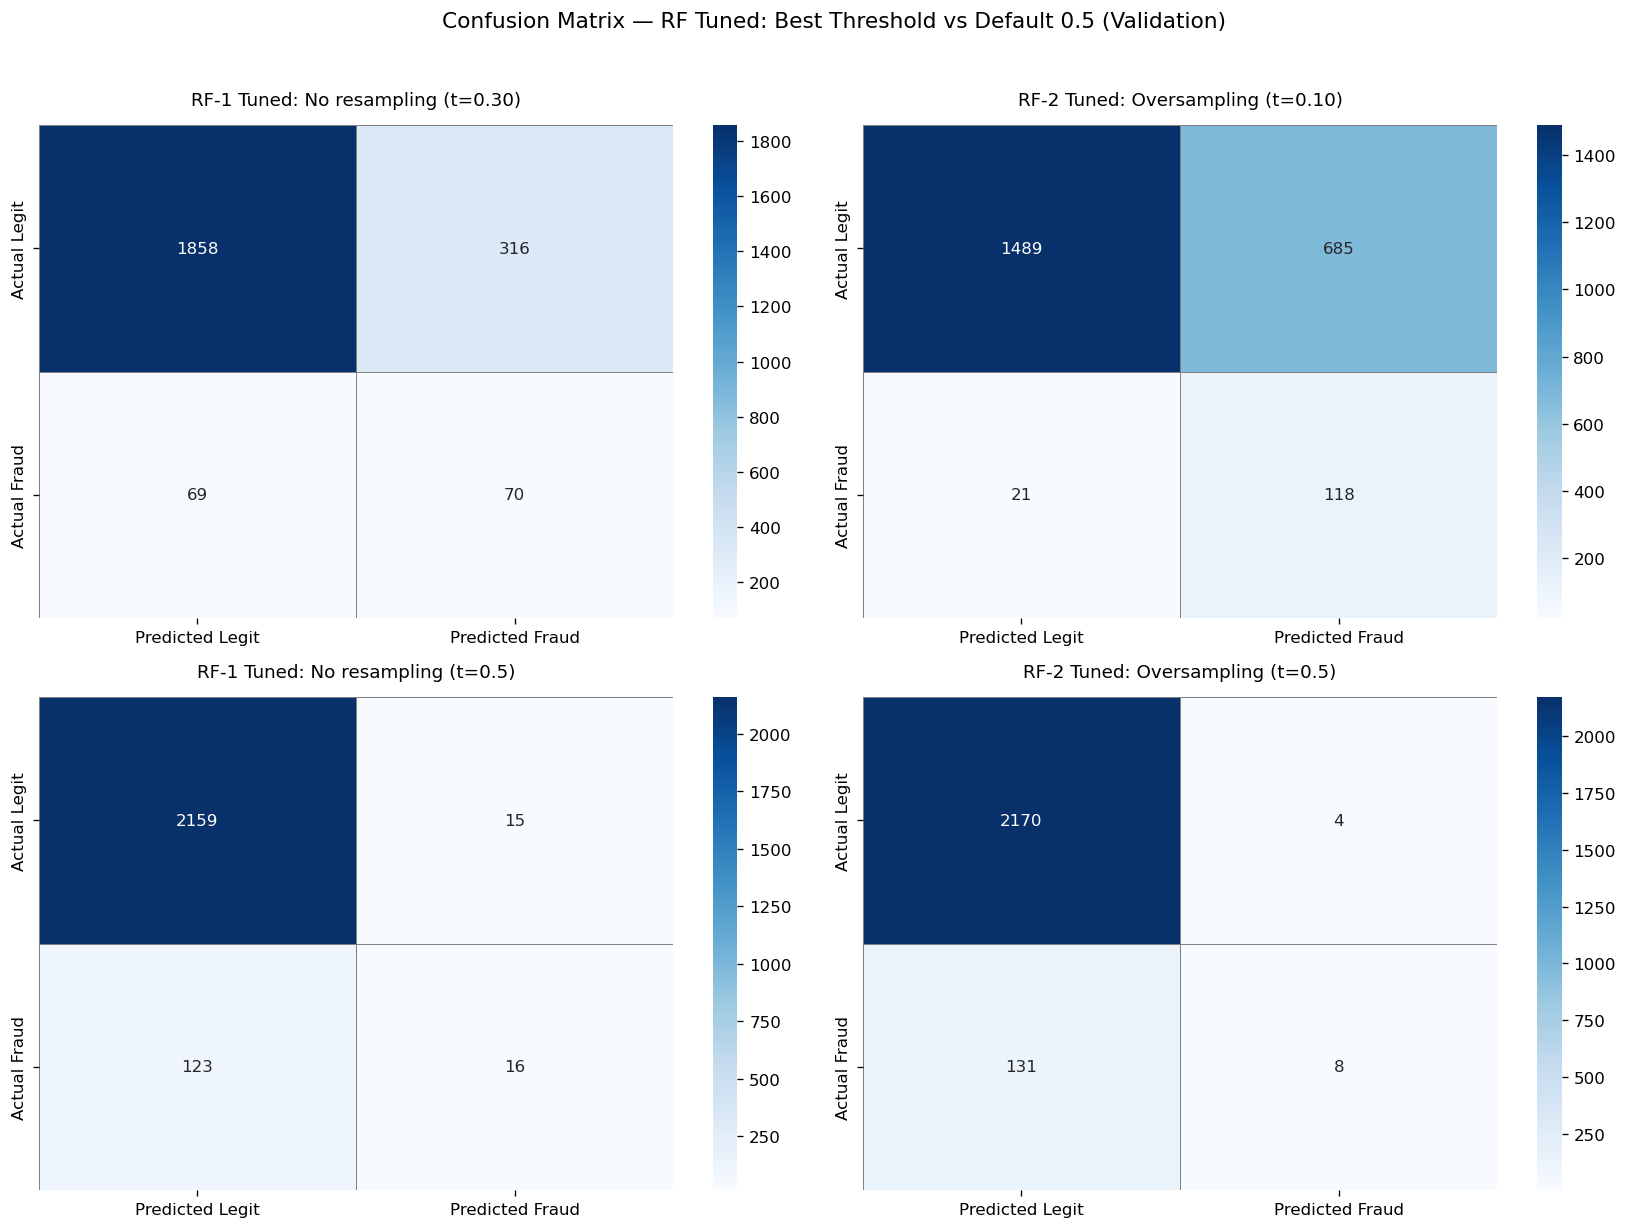

In [90]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Top row — best threshold
models_best = [
    (rf1_best_cm, f'RF-1 Tuned: No resampling (t={best_t_rf1:.2f})'),
    (rf2_best_cm, f'RF-2 Tuned: Oversampling (t={best_t_rf2:.2f})'),
]

for ax, (cm, title) in zip(axes[0], models_best):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Predicted Legit', 'Predicted Fraud'],
                yticklabels=['Actual Legit', 'Actual Fraud'],
                linewidths=0.5, linecolor='gray', ax=ax)
    ax.set_title(title, fontsize=11, pad=12)

# Bottom row — default threshold 0.5
models_default = [
    (rf1_tuned_val_cm, 'RF-1 Tuned: No resampling (t=0.5)'),
    (rf2_tuned_val_cm, 'RF-2 Tuned: Oversampling (t=0.5)'),
]

for ax, (cm, title) in zip(axes[1], models_default):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Predicted Legit', 'Predicted Fraud'],
                yticklabels=['Actual Legit', 'Actual Fraud'],
                linewidths=0.5, linecolor='gray', ax=ax)
    ax.set_title(title, fontsize=11, pad=12)

plt.suptitle('Confusion Matrix — RF Tuned: Best Threshold vs Default 0.5 (Validation)',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## Evaulation (threshold 0.5)

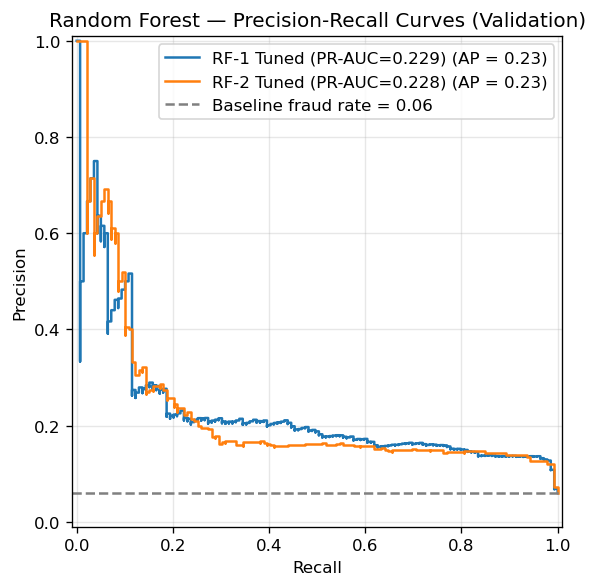

In [248]:
# Plot Precision-Recall curves for the tuned Random Forest models
fig, ax = plt.subplots(figsize=(7, 5))

PrecisionRecallDisplay.from_predictions(
    y_val, y_val_proba_rf1_tuned,
    name=f"RF-1 Tuned (PR-AUC={rf1_tuned_val_prauc:.3f})",
    ax=ax
)

PrecisionRecallDisplay.from_predictions(
    y_val, y_val_proba_rf2_tuned,
    name=f"RF-2 Tuned (PR-AUC={rf2_tuned_val_prauc:.3f})",
    ax=ax
)

# Add the baseline fraud rate for comparison
fraud_rate = y_val.mean()
ax.axhline(fraud_rate, color="gray", linestyle="--",
           label=f"Baseline fraud rate = {fraud_rate:.2f}")

ax.set_title("Random Forest — Precision-Recall Curves (Validation)")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.grid(alpha=0.3)
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

## evaluation

In [250]:
# Select the best Random Forest model based on PR-AUC performance
if rf1_best_prauc >= rf2_best_prauc:
    best_rf_model   = rf1_tuned
    best_rf_thresh  = best_t_rf1
    best_rf_proba   = y_val_proba_rf1_tuned
    best_rf_prauc   = rf1_best_prauc
    winner_rf_label = "RF-1 Tuned (no resampling)"
else:
    best_rf_model   = rf2_tuned
    best_rf_thresh  = best_t_rf2
    best_rf_proba   = y_val_proba_rf2_tuned
    best_rf_prauc   = rf2_best_prauc
    winner_rf_label = "RF-2 Tuned (oversampling)"

print(f"\nWinner: {winner_rf_label}")
print(f"Threshold applied to test set: {best_rf_thresh:.2f}")


Winner: RF-1 Tuned (no resampling)
Threshold applied to test set: 0.30


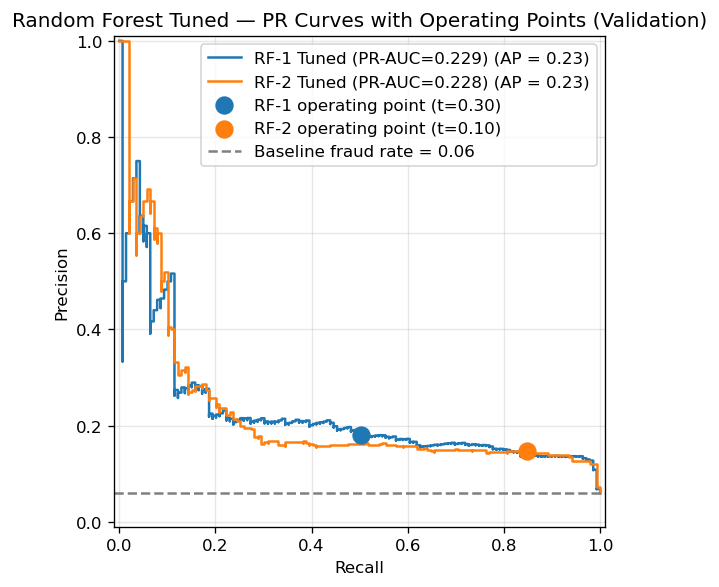

In [252]:
# Plot Precision-Recall curves for the tuned Random Forest models
fig, ax = plt.subplots(figsize=(7, 5))

PrecisionRecallDisplay.from_predictions(
    y_val, y_val_proba_rf1_tuned,
    name=f"RF-1 Tuned (PR-AUC={rf1_tuned_val_prauc:.3f})",
    ax=ax
)

PrecisionRecallDisplay.from_predictions(
    y_val, y_val_proba_rf2_tuned,
    name=f"RF-2 Tuned (PR-AUC={rf2_tuned_val_prauc:.3f})",
    ax=ax
)

# Mark the operating points corresponding to the selected thresholds
for proba, thresh, label in [
    (y_val_proba_rf1_tuned, best_t_rf1, f"RF-1 operating point (t={best_t_rf1:.2f})"),
    (y_val_proba_rf2_tuned, best_t_rf2, f"RF-2 operating point (t={best_t_rf2:.2f})"),
]:
    preds = (proba >= thresh).astype(int)
    p = precision_score(y_val, preds, zero_division=0)
    r = recall_score(y_val, preds, zero_division=0)
    ax.scatter(r, p, s=100, zorder=5, label=label)

# Add the baseline fraud rate for comparison
fraud_rate = y_val.mean()
ax.axhline(fraud_rate, color="gray", linestyle="--",
           label=f"Baseline fraud rate = {fraud_rate:.2f}")

ax.set_title("Random Forest Tuned — PR Curves with Operating Points (Validation)")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.grid(alpha=0.3)
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

## feature importance

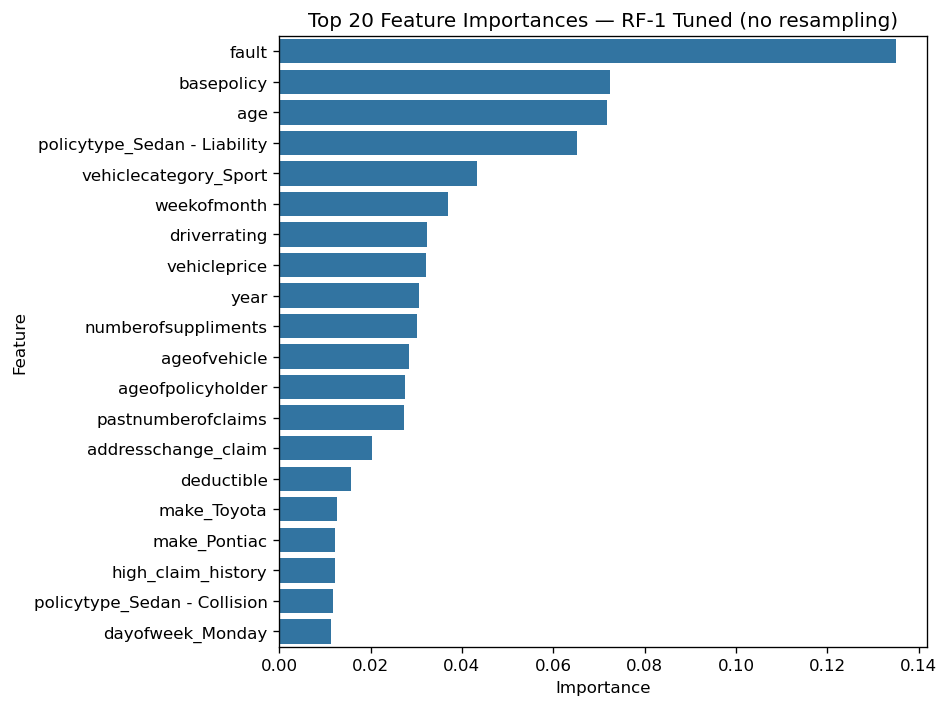

fault                           0.135051
basepolicy                      0.072379
age                             0.071765
policytype_Sedan - Liability    0.065131
vehiclecategory_Sport           0.043237
weekofmonth                     0.036868
driverrating                    0.032275
vehicleprice                    0.032121
year                            0.030630
numberofsuppliments             0.030247
ageofvehicle                    0.028359
ageofpolicyholder               0.027431
pastnumberofclaims              0.027219
addresschange_claim             0.020206
deductible                      0.015805
make_Toyota                     0.012760
make_Pontiac                    0.012317
high_claim_history              0.012200
policytype_Sedan - Collision    0.011784
dayofweek_Monday                0.011369
dtype: float64


In [98]:
importances = pd.Series(
    best_rf_model.feature_importances_,
    index=X_train.columns
)
top20 = importances.sort_values(ascending=False).head(20)

fig, ax = plt.subplots(figsize=(8, 6))
sns.barplot(x=top20.values, y=top20.index, ax=ax)
ax.set_title(f"Top 20 Feature Importances — {winner_rf_label}")
ax.set_xlabel("Importance")
ax.set_ylabel("Feature")
plt.tight_layout()
plt.show()

print(top20)

---
## 13. XGBoost

XGBoost (Extreme Gradient Boosting) is a sequential ensemble algorithm that constructs decision trees sequentially by learning from the errors of the preceding one. It is considered to be one of the most powerful models for structured tabular data especially where the problem of class imbalance exists because it naturally provides support for the `scale_pos_weight` hyperparameter that adds penalty for the misclassification of minority class instances.

Three base experiments are run using XGBoost with three different configurations: XGB-1 with no resampling, XGB-2 with random oversampling, and XGB-3 with SMOTE. In the case of no resampling, the value of `scale_pos_weight` is 15.7 representing the ratio of class imbalance in the training set (i.e., 15.7). It means that each classification error made on the fraud class is penalized 15.7 times more than that of the other class.

**Hyperparameter tuning procces uses the coarse-to-fine approach presented in the course. During the coarse search, `RandomizedSearchCV` selects 15 random configurations from a wide range of hyperparameters, including `n_estimators`, `learning_rate`, `max_depth`, `subsample`, `colsample_bytree`, `reg_lambda`, and `min_child_weight`. For each configuration, a 3-fold stratified cross-validation is carried out on the training set based on `average_precision` metric. This method allows for the quick identification of the most interesting part of the hyperparameter space without exploring all possible configurations. For the fine search, a manual grid search is used on the three most important hyperparameters (`n_estimators`, `max_depth`, and `learning_rate`) over 27 configurations close to the best values obtained from the coarse search. All remaining hyperparameters are kept fixed. Evaluation of models is performed on the validation set, not using cross-validation since it would be redundant for the small number of models under consideration.ation threshold of 0.5 is arbitrary and typically suboptimal for imbalanced datasets. A threshold sweep is performed from 0.10 to 0.80 in steps of 0.05, computing precision, recall, and F1 on the validation set at each point. The threshold that maximises F1 is selected: 0.55 for XGB-1 Tuned and 0.60 for XGB-2 Tuned. This threshold is then applied once to the test set for the final evaluation.

**SMOTE-NC implementation:** On the advice of the professor during the presentation, we decided to implement SMOTE-NC (SMOTE for Nominal and Continuous features), which would be a better choice than the regular SMOTE in case of presence of categorical features in our data set. According to the professor, the problem with the regular SMOTE algorithm in relation to categorical features is that interpolation between encoded features produces meaningless categories. The solution of SMOTE-NC to this problem is that it uses the most common category of neighbors for categorical features and interpolation for numerical features as in the regular SMOTE algorithm. Thus, the generated sample will have realistic category combinations. However, despite the improvements made to SMOTE, SMOTE-NC provided only 0.101 recall and PR-AUC of 0.238 — which is an improvement compared to regular SMOTE (recall 0.079, PR-AUC 0.267), but is still far from the best result of the XGBoost model.

# XGBoost

In [100]:
def build_xgb_model(scale_pos_weight=1.0):
    # Core XGBoost model
    model = xgb.XGBClassifier(
        objective="binary:logistic",
        eval_metric="aucpr",
        n_estimators=300,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=1.0,
        scale_pos_weight=scale_pos_weight,
        random_state=42,
        n_jobs=1
    )
    
    return model

###  XGB-1: no resampling

In [102]:
# Keep original training data
X_train_nr, y_train_nr = no_resampling(X_train, y_train)

# Compute imbalance ratio
neg = (y_train_nr == 0).sum()
pos = (y_train_nr == 1).sum()
scale_pos_weight = neg / pos

# Build model
xgb_xgb1 = build_xgb_model(scale_pos_weight=scale_pos_weight)

# Fit model
xgb_xgb1.fit(X_train_nr, y_train_nr)

# Compute validation predictions
y_val_proba_xgb1 = xgb_xgb1.predict_proba(X_val)[:, 1]
y_val_pred_xgb1 = (y_val_proba_xgb1 >= 0.5).astype(int)

# Compute validation metrics
xgb1_val_pr_auc = average_precision_score(y_val, y_val_proba_xgb1)
xgb1_val_roc_auc = roc_auc_score(y_val, y_val_proba_xgb1)
xgb1_val_precision = precision_score(y_val, y_val_pred_xgb1, zero_division=0)
xgb1_val_recall = recall_score(y_val, y_val_pred_xgb1, zero_division=0)
xgb1_val_f1 = f1_score(y_val, y_val_pred_xgb1, zero_division=0)
xgb1_val_cm = confusion_matrix(y_val, y_val_pred_xgb1)

### XGB-2: Random Oversampling

In [104]:
# Resample training data
X_train_ros, y_train_ros = random_oversampling(X_train, y_train)

# Build model
xgb_xgb2 = build_xgb_model(scale_pos_weight=1.0)

# Fit model
xgb_xgb2.fit(X_train_ros, y_train_ros)

# Compute validation predictions
y_val_proba_xgb2 = xgb_xgb2.predict_proba(X_val)[:, 1]
y_val_pred_xgb2 = (y_val_proba_xgb2 >= 0.5).astype(int)

# Compute validation metrics
xgb2_val_pr_auc = average_precision_score(y_val, y_val_proba_xgb2)
xgb2_val_roc_auc = roc_auc_score(y_val, y_val_proba_xgb2)
xgb2_val_precision = precision_score(y_val, y_val_pred_xgb2, zero_division=0)
xgb2_val_recall = recall_score(y_val, y_val_pred_xgb2, zero_division=0)
xgb2_val_f1 = f1_score(y_val, y_val_pred_xgb2, zero_division=0)
xgb2_val_cm = confusion_matrix(y_val, y_val_pred_xgb2)

### XGB-3: SMOTE


In [106]:
# XGB-3: SMOTE

# Resample training data with SMOTE
X_train_smote, y_train_smote = smote_resampling(X_train, y_train)

# Build model
xgb_xgb3 = build_xgb_model(scale_pos_weight=1.0)

# Fit model
xgb_xgb3.fit(X_train_smote, y_train_smote)

# Compute Validation predictions
y_val_proba_xgb3 = xgb_xgb3.predict_proba(X_val)[:, 1]
y_val_pred_xgb3 = (y_val_proba_xgb3 >= 0.5).astype(int)

# Compute Validation metrics
xgb3_val_pr_auc = average_precision_score(y_val, y_val_proba_xgb3)
xgb3_val_roc_auc = roc_auc_score(y_val, y_val_proba_xgb3)
xgb3_val_precision = precision_score(y_val, y_val_pred_xgb3, zero_division=0)
xgb3_val_recall = recall_score(y_val, y_val_pred_xgb3, zero_division=0)
xgb3_val_f1 = f1_score(y_val, y_val_pred_xgb3, zero_division=0)
xgb3_val_cm = confusion_matrix(y_val, y_val_pred_xgb3)

# Metrics Summary Table

In [108]:
# XGBoost - Validation results
val_results_xgb = pd.DataFrame({
    'Model':     ['XGB-1 (no resampling)', 'XGB-2 (oversampling)', 'XGB-3 (SMOTE)'],
    'PR-AUC':    [xgb1_val_pr_auc,    xgb2_val_pr_auc,    xgb3_val_pr_auc],
    'ROC-AUC':   [xgb1_val_roc_auc,   xgb2_val_roc_auc,   xgb3_val_roc_auc],
    'Precision': [xgb1_val_precision,  xgb2_val_precision,  xgb3_val_precision],
    'Recall':    [xgb1_val_recall,     xgb2_val_recall,     xgb3_val_recall],
    'F1':        [xgb1_val_f1,         xgb2_val_f1,         xgb3_val_f1],
}).round(4)

print("=== XGBoost — Validation Results ===")
print(val_results_xgb.to_string(index=False))


=== XGBoost — Validation Results ===
                Model  PR-AUC  ROC-AUC  Precision  Recall     F1
XGB-1 (no resampling)  0.2733   0.8487     0.1714  0.7842 0.2813
 XGB-2 (oversampling)  0.2951   0.8541     0.1657  0.7986 0.2744
        XGB-3 (SMOTE)  0.2768   0.8501     0.6364  0.1007 0.1739


# Confusion Matrices

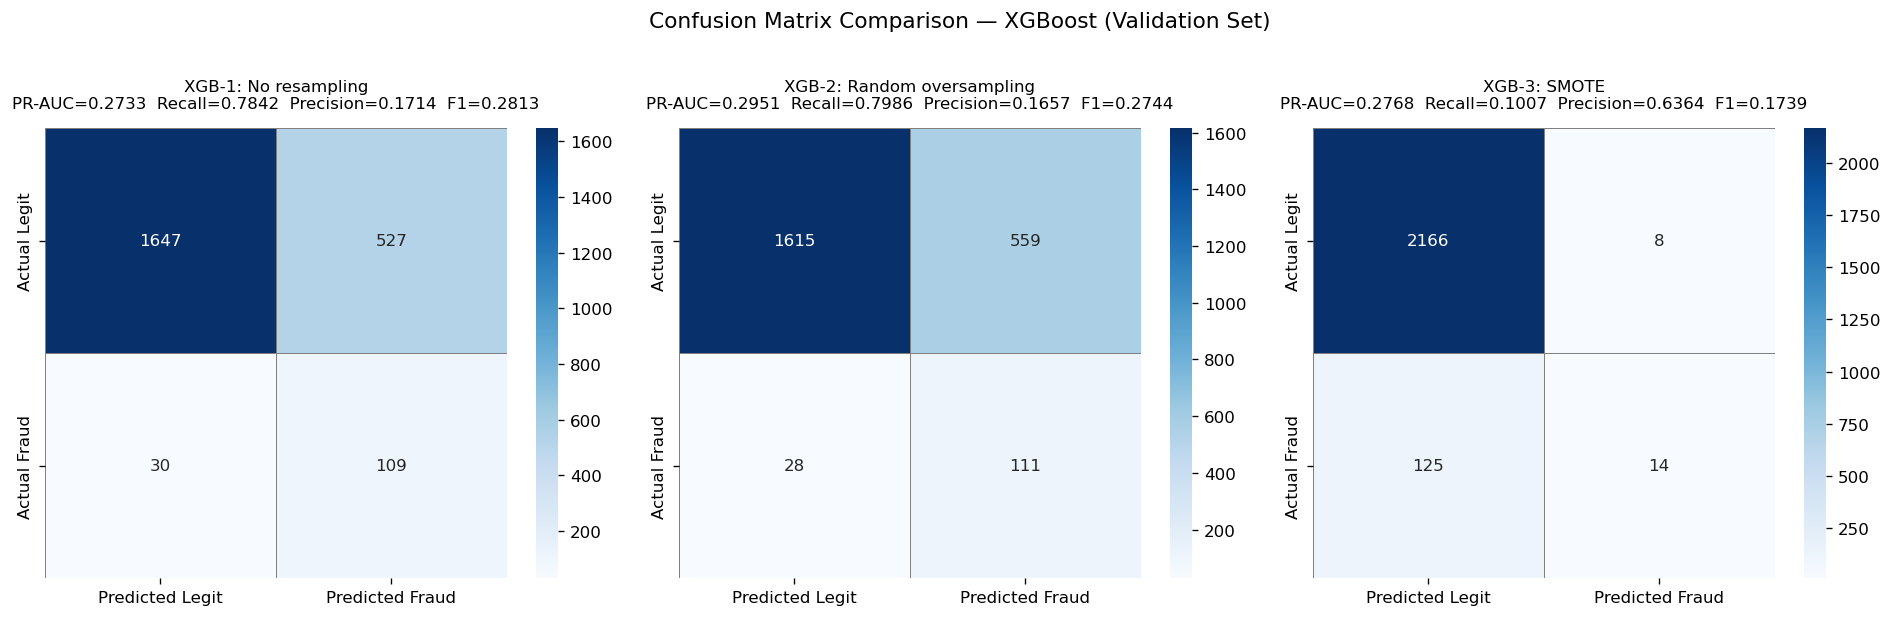

In [254]:
# Compare confusion matrices and validation metrics across the three XGBoost models
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

models_xgb = [
    (xgb1_val_cm, 'XGB-1: No resampling',      xgb1_val_pr_auc, xgb1_val_recall, xgb1_val_precision, xgb1_val_f1),
    (xgb2_val_cm, 'XGB-2: Random oversampling', xgb2_val_pr_auc, xgb2_val_recall, xgb2_val_precision, xgb2_val_f1),
    (xgb3_val_cm, 'XGB-3: SMOTE',               xgb3_val_pr_auc, xgb3_val_recall, xgb3_val_precision, xgb3_val_f1),
]

for ax, (cm, title, pr_auc, recall, precision, f1) in zip(axes, models_xgb):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Predicted Legit', 'Predicted Fraud'],
                yticklabels=['Actual Legit', 'Actual Fraud'],
                linewidths=0.5, linecolor='gray', ax=ax)
    ax.set_title(
        f"{title}\nPR-AUC={pr_auc:.4f}  Recall={recall:.4f}  Precision={precision:.4f}  F1={f1:.4f}",
        fontsize=10, pad=12
    )

plt.suptitle('Confusion Matrix Comparison — XGBoost (Validation Set)',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# XGBoost Hyperparameter Tuning — Coarse-to-Fine Search

As per the methodology of the course (Lecture 12), we use the **coarse-to-fine** approach:

1. **Coarse stage** – `RandomizedSearchCV` with 15 randomized parameter combinations over
   a wide range, using 3-fold stratified cross-validation on the training data. Finds a
   promising area in the parameter space.

2. **Fine stage** – Fine-tuned manual grid search on the top three parameters
   (`n_estimators`, `max_depth`, `learning_rate`) near the coarse best combination,
   with all other parameters fixed to the coarse best combination.

3. **Threshold tuning** – The default threshold of 0.5 is arbitrary. We perform a manual
   sweep over various thresholds on the **validation set alone**, finding the best
   precision-recall trade-off.

4. **Test evaluation** – The test data is used only **once**, for evaluating the best
   found model and the best threshold found on the validation set.

Important constraint: validation and test data are never involved in training/tuning.
Scoring metric: `average_precision` (= PR-AUC), same as our primary evaluation metric.

### Coarse Random Search — XGB-1 (no resampling)
 
We sample 15 random combinations from a broad distribution.
Scoring is `average_precision` (PR-AUC) via 3-fold CV on training data.

In [259]:
# We sample 15 random combinations from a broad hyperparameter distribution.
# The model is evaluated with average precision (PR-AUC) using 3-fold cross-validation on the training data.

neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale_pos_weight = neg / pos
print(f"Class imbalance ratio: {scale_pos_weight:.1f}x  (used as scale_pos_weight)")
 
coarse_param_dist = {
    "n_estimators":     [200, 400],
    "learning_rate":    [0.03, 0.05, 0.08],
    "max_depth":        [3, 4, 5],
    "subsample":        [0.7, 0.9],
    "colsample_bytree": [0.7, 1.0],
    "reg_lambda":       [0.5, 2.0],
    "min_child_weight": [1, 5],
}
 
base_xgb1 = xgb.XGBClassifier(
    objective="binary:logistic",
    eval_metric="aucpr",
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_jobs=-1,
    tree_method="hist",
)
 
coarse_search_xgb1 = RandomizedSearchCV(
    base_xgb1,
    coarse_param_dist,
    n_iter=15,
    scoring="average_precision",
    cv=cv,
    random_state=42,
    n_jobs=1,
    verbose=0,
)
coarse_search_xgb1.fit(X_train, y_train)
 
coarse_best_xgb1 = coarse_search_xgb1.best_params_
print(f"\nCoarse best CV PR-AUC: {coarse_search_xgb1.best_score_:.4f}")
print(f"Coarse best params:    {coarse_best_xgb1}")

Class imbalance ratio: 15.7x  (used as scale_pos_weight)

Coarse best CV PR-AUC: 0.2328
Coarse best params:    {'subsample': 0.9, 'reg_lambda': 0.5, 'n_estimators': 400, 'min_child_weight': 1, 'max_depth': 5, 'learning_rate': 0.03, 'colsample_bytree': 1.0}


### Fine Manual Grid — XGB-1


In [262]:
# We fix the coarse best values for `subsample`, `colsample_bytree`, `reg_lambda`,
# and `min_child_weight`, then run a fine grid over the three most important parameters:
# `n_estimators`, `max_depth`, and `learning_rate`.
#
# This follows a coarse-to-fine strategy: first use random search to find the right region,
# then use a smaller grid search to refine the best combination.

fine_results_xgb1 = []

for n_est in [350, 400, 500]:
    for depth in [4, 5, 6]:
        for lr in [0.02, 0.03, 0.05]:
            m = xgb.XGBClassifier(
                objective="binary:logistic",
                eval_metric="aucpr",
                n_estimators=n_est,
                learning_rate=lr,
                max_depth=depth,
                subsample=0.9,
                colsample_bytree=1.0,
                reg_lambda=0.5,
                min_child_weight=1,
                scale_pos_weight=scale_pos_weight,
                random_state=42,
                n_jobs=1,
                tree_method="hist",
            )
            m.fit(X_train, y_train)
            p = m.predict_proba(X_val)[:, 1]
            score = average_precision_score(y_val, p)
            fine_results_xgb1.append({
                "n_estimators": n_est,
                "max_depth": depth,
                "learning_rate": lr,
                "val_pr_auc": round(score, 4),
            })

fine_df_xgb1 = pd.DataFrame(fine_results_xgb1).sort_values("val_pr_auc", ascending=False)
print("Fine grid results (top 10):")
print(fine_df_xgb1.head(10).to_string(index=False))

best_fine_xgb1 = fine_df_xgb1.iloc[0]
print(f"\nBest fine params: n_estimators={int(best_fine_xgb1['n_estimators'])}, "
      f"max_depth={int(best_fine_xgb1['max_depth'])}, learning_rate={best_fine_xgb1['learning_rate']}")
print(f"Val PR-AUC: {best_fine_xgb1['val_pr_auc']:.4f}")

Fine grid results (top 10):
 n_estimators  max_depth  learning_rate  val_pr_auc
          500          5           0.02      0.2875
          400          5           0.02      0.2861
          350          5           0.03      0.2845
          400          5           0.03      0.2843
          500          5           0.03      0.2836
          500          4           0.03      0.2833
          500          6           0.02      0.2826
          350          5           0.02      0.2824
          400          6           0.02      0.2816
          500          4           0.02      0.2815

Best fine params: n_estimators=500, max_depth=5, learning_rate=0.02
Val PR-AUC: 0.2875


In [267]:
# Train the tuned XGBoost model using the best hyperparameters found in the fine grid
xgb1_tuned = xgb.XGBClassifier(
    objective="binary:logistic",
    eval_metric="aucpr",
    n_estimators=int(best_fine_xgb1["n_estimators"]),
    learning_rate=best_fine_xgb1["learning_rate"],
    max_depth=int(best_fine_xgb1["max_depth"]),
    subsample=0.9,
    colsample_bytree=1.0,
    reg_lambda=0.5,
    min_child_weight=1,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_jobs=1,
    tree_method="hist",
)
xgb1_tuned.fit(X_train, y_train)

# Predict probabilities and class labels on the validation set
y_val_proba_xgb1_tuned = xgb1_tuned.predict_proba(X_val)[:, 1]
y_val_pred_xgb1_tuned    = (y_val_proba_xgb1_tuned >= 0.5).astype(int)

# Evaluate the tuned model on validation data
xgb1_tuned_val_prauc  = average_precision_score(y_val, y_val_proba_xgb1_tuned)
xgb1_tuned_val_rocauc = roc_auc_score(y_val, y_val_proba_xgb1_tuned)

xgb1_tuned_val_precision = precision_score(y_val, y_val_pred_xgb1_tuned, zero_division=0)
xgb1_tuned_val_recall    = recall_score(y_val, y_val_pred_xgb1_tuned, zero_division=0)
xgb1_tuned_val_f1        = f1_score(y_val, y_val_pred_xgb1_tuned, zero_division=0)

print(f"XGB-1 Tuned | Val PR-AUC: {xgb1_tuned_val_prauc:.4f}  Val ROC-AUC: {xgb1_tuned_val_rocauc:.4f}")
print(f"             Precision:   {xgb1_tuned_val_precision:.4f}  Recall: {xgb1_tuned_val_recall:.4f}  F1: {xgb1_tuned_val_f1:.4f}")


XGB-1 Tuned | Val PR-AUC: 0.2875  Val ROC-AUC: 0.8541
             Precision:   0.1738  Recall: 0.8129  F1: 0.2864


### Threshold Tuning — XGB-1

XGB-1 Threshold sweep (validation):
 threshold  precision  recall    f1
      0.10      0.114   0.986 0.204
      0.15      0.123   0.957 0.218
      0.20      0.129   0.942 0.227
      0.25      0.135   0.928 0.236
      0.30      0.142   0.921 0.247
      0.35      0.146   0.899 0.252
      0.40      0.155   0.892 0.264
      0.45      0.164   0.849 0.275
      0.50      0.174   0.813 0.286
      0.55      0.189   0.719 0.299
      0.60      0.214   0.647 0.322
      0.65      0.215   0.482 0.298
      0.70      0.234   0.324 0.272
      0.75      0.276   0.230 0.251
      0.80      0.346   0.129 0.188

=> Best threshold: 0.60  F1=0.322  Precision=0.214  Recall=0.647


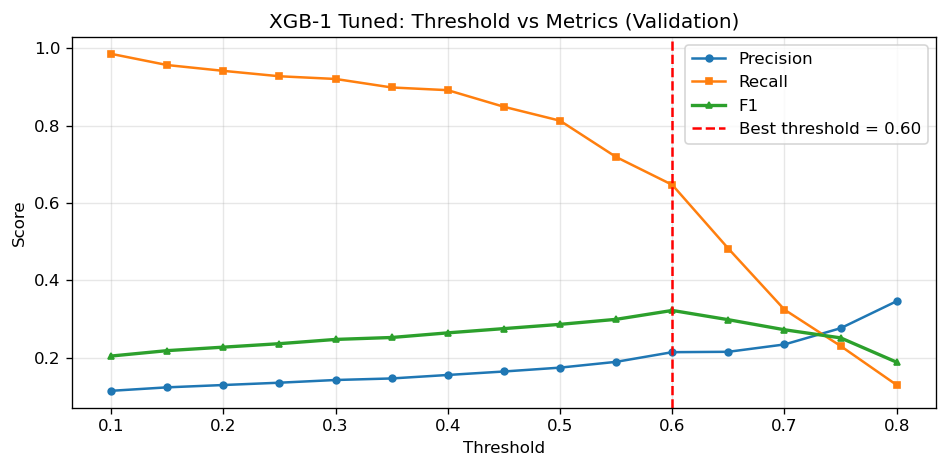

In [269]:
# The default threshold of 0.5 is arbitrary. We sweep thresholds on the validation set
# and choose the one that maximises F1.
#
# The threshold is selected only on validation data; the test set is not used here.

thresholds = np.arange(0.10, 0.85, 0.05)
thresh_rows_xgb1 = []
 
for t in thresholds:
    preds = (y_val_proba_xgb1_tuned >= t).astype(int)
    thresh_rows_xgb1.append({
        "threshold": round(t, 2),
        "precision": round(precision_score(y_val, preds, zero_division=0), 3),
        "recall":    round(recall_score(y_val, preds, zero_division=0), 3),
        "f1":        round(f1_score(y_val, preds, zero_division=0), 3),
    })
 
thresh_df_xgb1 = pd.DataFrame(thresh_rows_xgb1)
best_idx_xgb1  = thresh_df_xgb1["f1"].idxmax()
best_t_xgb1    = thresh_df_xgb1.loc[best_idx_xgb1, "threshold"]
print("XGB-1 Threshold sweep (validation):")
print(thresh_df_xgb1.to_string(index=False))
print(f"\n=> Best threshold: {best_t_xgb1:.2f}  "
      f"F1={thresh_df_xgb1.loc[best_idx_xgb1,'f1']:.3f}  "
      f"Precision={thresh_df_xgb1.loc[best_idx_xgb1,'precision']:.3f}  "
      f"Recall={thresh_df_xgb1.loc[best_idx_xgb1,'recall']:.3f}")
 
# Plot threshold vs precision, recall, and F1
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(thresh_df_xgb1["threshold"], thresh_df_xgb1["precision"], label="Precision", marker="o", ms=4)
ax.plot(thresh_df_xgb1["threshold"], thresh_df_xgb1["recall"],    label="Recall",    marker="s", ms=4)
ax.plot(thresh_df_xgb1["threshold"], thresh_df_xgb1["f1"],        label="F1",        marker="^", ms=4, lw=2)
ax.axvline(best_t_xgb1, color="red", linestyle="--", label=f"Best threshold = {best_t_xgb1:.2f}")
ax.set_xlabel("Threshold"); ax.set_ylabel("Score"); ax.set_title("XGB-1 Tuned: Threshold vs Metrics (Validation)")
ax.legend(); ax.grid(True, alpha=0.3); plt.tight_layout(); plt.show()
 

### Coarse-to-Fine Tuning — XGB-2 (Random Oversampling)

In [271]:
# We repeat the same two-stage tuning process for XGB-2.
# First we apply random oversampling to the training data.

X_train_ros, y_train_ros = random_oversampling(X_train, y_train)
 
coarse_search_xgb2 = RandomizedSearchCV(
    xgb.XGBClassifier(
        objective="binary:logistic", eval_metric="aucpr",
        scale_pos_weight=1.0, random_state=42, n_jobs=-1, tree_method="hist",
    ),
    coarse_param_dist,
    n_iter=15,
    scoring="average_precision",
    cv=cv,
    random_state=42,
    n_jobs=1,
    verbose=0,
)
coarse_search_xgb2.fit(X_train_ros, y_train_ros)
coarse_best_xgb2 = coarse_search_xgb2.best_params_
print(f"XGB-2 Coarse best CV PR-AUC: {coarse_search_xgb2.best_score_:.4f}")
print(f"XGB-2 Coarse best params:    {coarse_best_xgb2}")
 
# Fine grid search for XGB-2 using the best region found in the coarse stage.
fine_results_xgb2 = []
for n_est in [350, 400, 500]:
    for depth in [4, 5, 6]:
        for lr in [0.02, 0.03, 0.05]:
            m = xgb.XGBClassifier(
                objective="binary:logistic", eval_metric="aucpr",
                n_estimators=n_est, learning_rate=lr, max_depth=depth,
                subsample=0.9, colsample_bytree=1.0, reg_lambda=0.5,
                min_child_weight=1, scale_pos_weight=1.0,
                random_state=42, n_jobs=-1, tree_method="hist",
            )
            m.fit(X_train_ros, y_train_ros)
            p = m.predict_proba(X_val)[:, 1]
            score = average_precision_score(y_val, p)
            fine_results_xgb2.append({"n_estimators": n_est, "max_depth": depth,
                                       "learning_rate": lr, "val_pr_auc": round(score, 4)})
 
fine_df_xgb2 = pd.DataFrame(fine_results_xgb2).sort_values("val_pr_auc", ascending=False)
print("\nXGB-2 Fine grid results (top 10):")
print(fine_df_xgb2.head(10).to_string(index=False))

best_fine_xgb2 = fine_df_xgb2.iloc[0]
print(f"\nBest fine params: n_estimators={int(best_fine_xgb2['n_estimators'])}, "
      f"max_depth={int(best_fine_xgb2['max_depth'])}, learning_rate={best_fine_xgb2['learning_rate']}")
print(f"Val PR-AUC: {best_fine_xgb2['val_pr_auc']:.4f}")

XGB-2 Coarse best CV PR-AUC: 0.9802
XGB-2 Coarse best params:    {'subsample': 0.9, 'reg_lambda': 2.0, 'n_estimators': 400, 'min_child_weight': 1, 'max_depth': 5, 'learning_rate': 0.08, 'colsample_bytree': 1.0}

XGB-2 Fine grid results (top 10):
 n_estimators  max_depth  learning_rate  val_pr_auc
          400          5           0.05      0.3023
          350          5           0.05      0.3022
          500          5           0.05      0.2990
          350          6           0.03      0.2957
          400          6           0.03      0.2914
          500          4           0.05      0.2904
          350          4           0.03      0.2900
          400          4           0.05      0.2892
          400          4           0.03      0.2888
          350          4           0.05      0.2885

Best fine params: n_estimators=400, max_depth=5, learning_rate=0.05
Val PR-AUC: 0.3023


In [273]:
# Select the best fine-tuned parameter combination for XGB-2
best_fine_xgb2 = fine_df_xgb2.iloc[0]

# Train the final XGB-2 model on the oversampled training data
xgb2_tuned = xgb.XGBClassifier(
    objective="binary:logistic",
    eval_metric="aucpr",
    n_estimators=int(best_fine_xgb2["n_estimators"]),
    learning_rate=best_fine_xgb2["learning_rate"],
    max_depth=int(best_fine_xgb2["max_depth"]),
    subsample=0.9,
    colsample_bytree=1.0,
    reg_lambda=0.5,
    min_child_weight=1,
    scale_pos_weight=1.0,
    random_state=42,
    n_jobs=1,
    tree_method="hist",
)
xgb2_tuned.fit(X_train_ros, y_train_ros)

# Predict probabilities and class labels on the validation set
y_val_proba_xgb2_tuned = xgb2_tuned.predict_proba(X_val)[:, 1]
y_val_pred_xgb2_tuned    = (y_val_proba_xgb2_tuned >= 0.5).astype(int)

# Compute validation metrics for the tuned XGB-2 model
xgb2_tuned_val_precision = precision_score(y_val, y_val_pred_xgb2_tuned, zero_division=0)
xgb2_tuned_val_recall    = recall_score(y_val, y_val_pred_xgb2_tuned, zero_division=0)
xgb2_tuned_val_f1        = f1_score(y_val, y_val_pred_xgb2_tuned, zero_division=0)
xgb2_tuned_val_prauc  = average_precision_score(y_val, y_val_proba_xgb2_tuned)
xgb2_tuned_val_rocauc = roc_auc_score(y_val, y_val_proba_xgb2_tuned)

print(f"XGB-2 Tuned | Val PR-AUC: {xgb2_tuned_val_prauc:.4f}  Val ROC-AUC: {xgb2_tuned_val_rocauc:.4f}")
print(f"             Precision:   {xgb2_tuned_val_precision:.4f}  Recall: {xgb2_tuned_val_recall:.4f}  F1: {xgb2_tuned_val_f1:.4f}")




XGB-2 Tuned | Val PR-AUC: 0.2917  Val ROC-AUC: 0.8626
             Precision:   0.2017  Recall: 0.6763  F1: 0.3107


XGB-2 Threshold sweep (validation):
 threshold  precision  recall    f1
      0.10      0.123   0.942 0.217
      0.15      0.137   0.935 0.239
      0.20      0.151   0.928 0.259
      0.25      0.157   0.885 0.267
      0.30      0.169   0.878 0.283
      0.35      0.174   0.820 0.288
      0.40      0.186   0.799 0.302
      0.45      0.197   0.755 0.313
      0.50      0.202   0.676 0.311
      0.55      0.220   0.619 0.325
      0.60      0.245   0.554 0.340
      0.65      0.259   0.460 0.332
      0.70      0.288   0.353 0.317
      0.75      0.268   0.216 0.239
      0.80      0.328   0.151 0.207

=> Best threshold: 0.60  F1=0.340  Precision=0.245  Recall=0.554


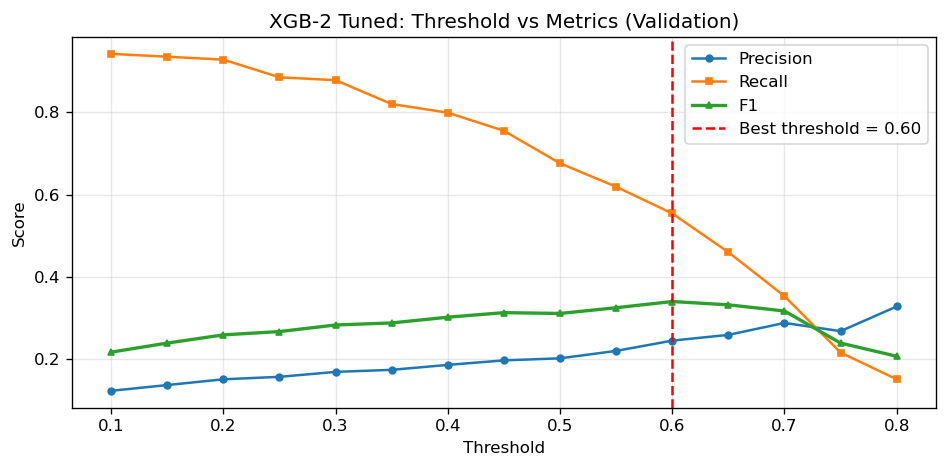

In [275]:
# Sweep thresholds on the validation set for XGB-2 and compute precision, recall, and F1
thresh_rows_xgb2 = []
for t in thresholds:
    preds = (y_val_proba_xgb2_tuned >= t).astype(int)
    thresh_rows_xgb2.append({
        "threshold": round(t, 2),
        "precision": round(precision_score(y_val, preds, zero_division=0), 3),
        "recall":    round(recall_score(y_val, preds, zero_division=0), 3),
        "f1":        round(f1_score(y_val, preds, zero_division=0), 3),
    })

# Store the threshold results in a dataframe and select the threshold with the best F1
thresh_df_xgb2 = pd.DataFrame(thresh_rows_xgb2)
best_idx_xgb2  = thresh_df_xgb2["f1"].idxmax()
best_t_xgb2    = thresh_df_xgb2.loc[best_idx_xgb2, "threshold"]
print("XGB-2 Threshold sweep (validation):")
print(thresh_df_xgb2.to_string(index=False))
print(f"\n=> Best threshold: {best_t_xgb2:.2f}  "
      f"F1={thresh_df_xgb2.loc[best_idx_xgb2,'f1']:.3f}  "
      f"Precision={thresh_df_xgb2.loc[best_idx_xgb2,'precision']:.3f}  "
      f"Recall={thresh_df_xgb2.loc[best_idx_xgb2,'recall']:.3f}")

# Plot how threshold changes precision, recall, and F1 for XGB-2
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(thresh_df_xgb2["threshold"], thresh_df_xgb2["precision"], label="Precision", marker="o", ms=4)
ax.plot(thresh_df_xgb2["threshold"], thresh_df_xgb2["recall"],    label="Recall",    marker="s", ms=4)
ax.plot(thresh_df_xgb2["threshold"], thresh_df_xgb2["f1"],        label="F1",        marker="^", ms=4, lw=2)
ax.axvline(best_t_xgb2, color="red", linestyle="--", label=f"Best threshold = {best_t_xgb2:.2f}")
ax.set_xlabel("Threshold"); ax.set_ylabel("Score"); ax.set_title("XGB-2 Tuned: Threshold vs Metrics (Validation)")
ax.legend(); ax.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

### Model Selection & Precision-Recall Curves

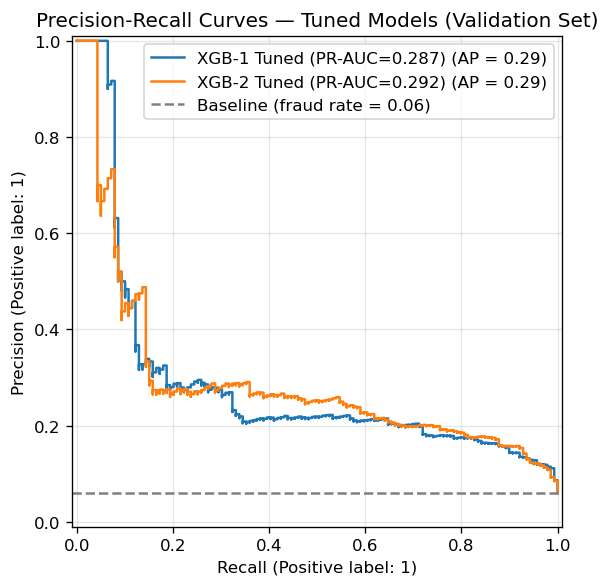

XGB-1 Tuned Val PR-AUC: 0.2875
XGB-2 Tuned Val PR-AUC: 0.2917

Winner: XGB-2 Tuned (random oversampling)
Threshold applied to test set: 0.60


In [278]:
# We compare XGB-1 and XGB-2 using validation PR-AUC, which is our main metric.
# The model with the better validation result is selected, and it will be evaluated once on the test set.

fig, ax = plt.subplots(figsize=(7, 5))
PrecisionRecallDisplay.from_predictions(
    y_val, y_val_proba_xgb1_tuned,
    name=f"XGB-1 Tuned (PR-AUC={xgb1_tuned_val_prauc:.3f})", ax=ax
)
PrecisionRecallDisplay.from_predictions(
    y_val, y_val_proba_xgb2_tuned,
    name=f"XGB-2 Tuned (PR-AUC={xgb2_tuned_val_prauc:.3f})", ax=ax
)
fraud_rate = y_val.mean()
ax.axhline(fraud_rate, color="gray", linestyle="--", label=f"Baseline (fraud rate = {fraud_rate:.2f})")
ax.set_title("Precision-Recall Curves — Tuned Models (Validation Set)")
ax.legend(loc="upper right"); ax.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

# Select the best tuned model based on validation PR-AUC
if xgb1_tuned_val_prauc >= xgb2_tuned_val_prauc:
    best_model_tuned  = xgb1_tuned
    best_thresh_tuned = best_t_xgb1
    winner_label      = "XGB-1 Tuned (no resampling)"
else:
    best_model_tuned  = xgb2_tuned
    best_thresh_tuned = best_t_xgb2
    winner_label      = "XGB-2 Tuned (random oversampling)"

print(f"XGB-1 Tuned Val PR-AUC: {xgb1_tuned_val_prauc:.4f}")
print(f"XGB-2 Tuned Val PR-AUC: {xgb2_tuned_val_prauc:.4f}")
print(f"\nWinner: {winner_label}")
print(f"Threshold applied to test set: {best_thresh_tuned:.2f}")

## Final evaulation (validation set)

=== Final Model Comparison — Validation ===
     Model  Threshold  PR-AUC  Precision  Recall     F1
 LR Winner       0.65  0.1779     0.1490  0.4964 0.2292
 RF Winner       0.30  0.2277     0.1469  0.8489 0.2505
XGB Winner       0.60  0.2917     0.2452  0.5540 0.3400


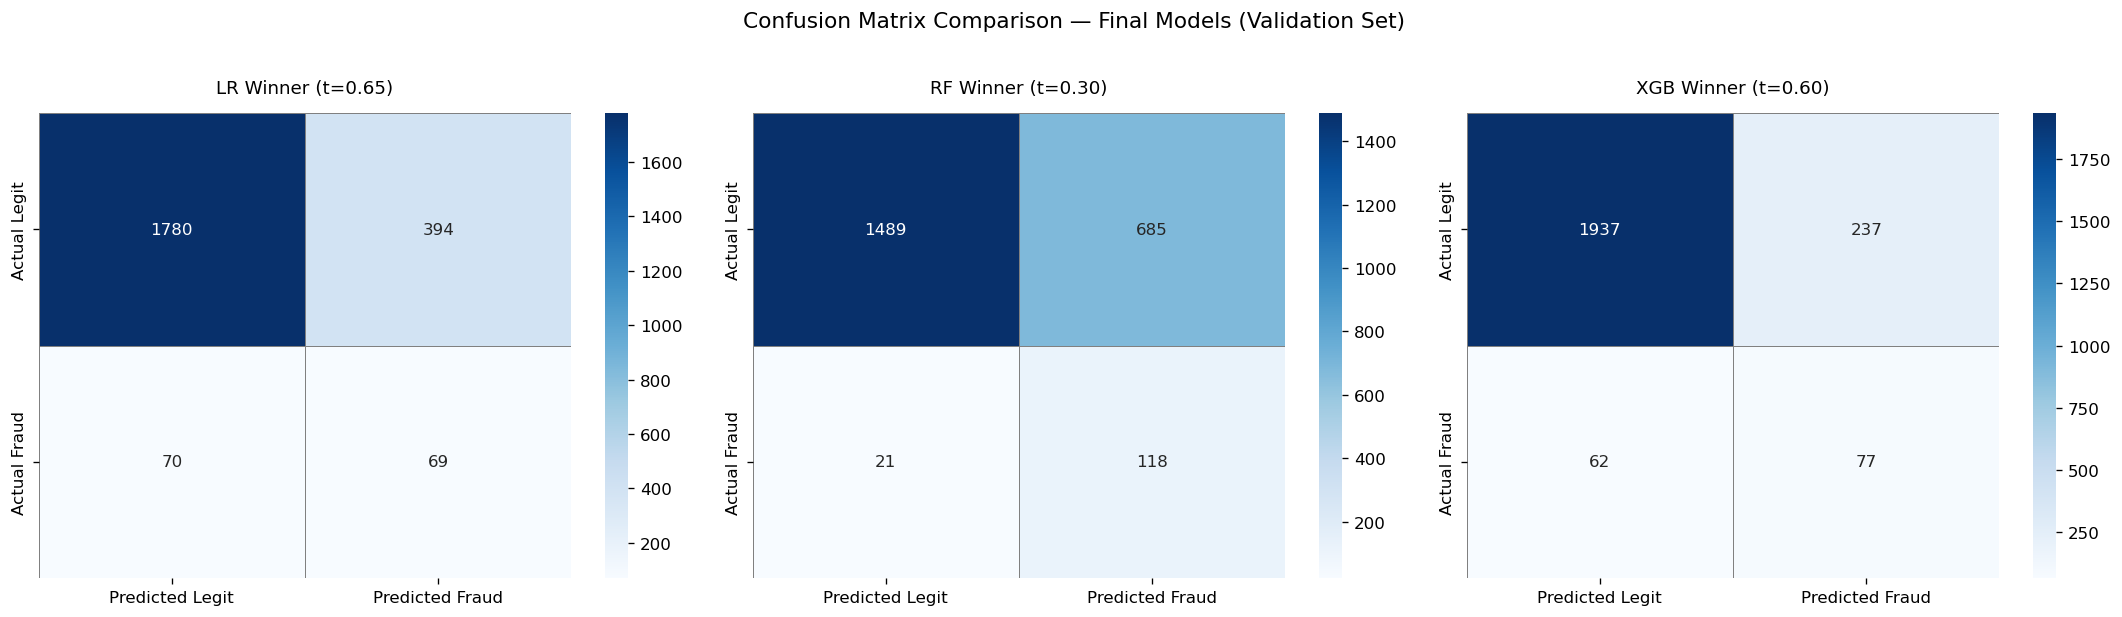

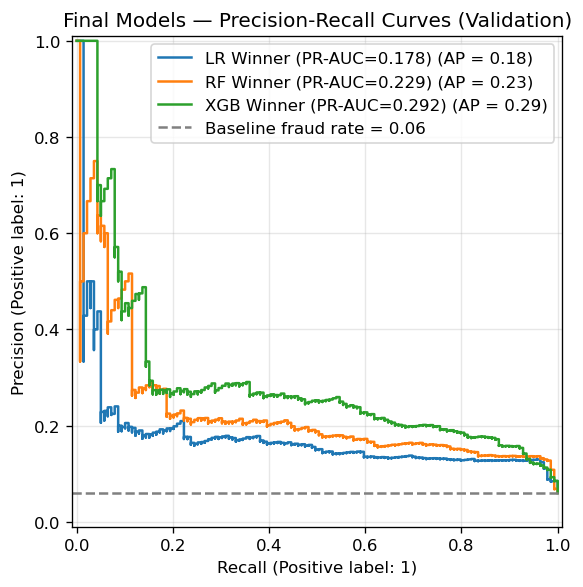

fraudfound
0    2174
1     139
Name: count, dtype: int64


In [127]:
# Recompute XGB winner val predictions using the actual winner
y_val_proba_xgb_winner = best_model_tuned.predict_proba(X_val)[:, 1]
y_val_pred_xgb_winner  = (y_val_proba_xgb_winner >= best_thresh_tuned).astype(int)

xgb_val_precision_final = precision_score(y_val, y_val_pred_xgb_winner, zero_division=0)
xgb_val_recall_final    = recall_score(y_val, y_val_pred_xgb_winner, zero_division=0)
xgb_val_f1_final        = f1_score(y_val, y_val_pred_xgb_winner, zero_division=0)
xgb_val_prauc_final     = average_precision_score(y_val, y_val_proba_xgb_winner)

results_final_val = pd.DataFrame({
    'Model':     ['LR Winner',          'RF Winner',       'XGB Winner'],
    'Threshold': [best_lr_threshold,    best_rf_thresh,    best_thresh_tuned],
    'PR-AUC':    [lr1_final_pr_auc,     rf2_best_prauc,    xgb_val_prauc_final],
    'Precision': [lr1_final_precision,  rf2_best_precision, xgb_val_precision_final],
    'Recall':    [lr1_final_recall,     rf2_best_recall,    xgb_val_recall_final],
    'F1':        [lr1_final_f1,         rf2_best_f1,        xgb_val_f1_final],
}).round(4)

print("=== Final Model Comparison — Validation ===")
print(results_final_val.to_string(index=False))

# Confusion matrices
xgb_val_cm_final = confusion_matrix(y_val, y_val_pred_xgb_winner)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

models_final_val = [
    (lr1_final_cm,     f'LR Winner (t={best_lr_threshold:.2f})'),
    (rf2_best_cm,      f'RF Winner (t={best_rf_thresh:.2f})'),
    (xgb_val_cm_final, f'XGB Winner (t={best_thresh_tuned:.2f})'),
]

for ax, (cm, title) in zip(axes, models_final_val):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Predicted Legit', 'Predicted Fraud'],
                yticklabels=['Actual Legit', 'Actual Fraud'],
                linewidths=0.5, linecolor='gray', ax=ax)
    ax.set_title(title, fontsize=11, pad=12)

plt.suptitle('Confusion Matrix Comparison — Final Models (Validation Set)',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# PR curves
fig, ax = plt.subplots(figsize=(7, 5))

PrecisionRecallDisplay.from_predictions(y_val, y_val_proba_lr1_tuned,
    name=f"LR Winner (PR-AUC={lr1_final_pr_auc:.3f})", ax=ax)
PrecisionRecallDisplay.from_predictions(y_val, best_rf_proba,
    name=f"RF Winner (PR-AUC={best_rf_prauc:.3f})", ax=ax)
PrecisionRecallDisplay.from_predictions(y_val, y_val_proba_xgb_winner,
    name=f"XGB Winner (PR-AUC={xgb_val_prauc_final:.3f})", ax=ax)

fraud_rate = y_val.mean()
ax.axhline(fraud_rate, color="gray", linestyle="--",
           label=f"Baseline fraud rate = {fraud_rate:.2f}")
ax.set_title("Final Models — Precision-Recall Curves (Validation)")
ax.grid(alpha=0.3)
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

print(y_val.value_counts())

## Test set comparison

In [129]:
# Test set predictions for each winner

# LR winner
y_test_proba_lr  = lr1_tuned.predict_proba(X_test)[:, 1]
y_test_pred_lr   = (y_test_proba_lr >= best_lr_threshold).astype(int)

# RF winner
y_test_proba_rf  = best_rf_model.predict_proba(X_test)[:, 1]
y_test_pred_rf   = (y_test_proba_rf >= best_rf_thresh).astype(int)

# XGB winner
y_test_proba_xgb = best_model_tuned.predict_proba(X_test)[:, 1]
y_test_pred_xgb  = (y_test_proba_xgb >= best_thresh_tuned).astype(int)

# Metrics
lr_test_prauc     = average_precision_score(y_test, y_test_proba_lr)
lr_test_rocauc    = roc_auc_score(y_test, y_test_proba_lr)
lr_test_precision = precision_score(y_test, y_test_pred_lr, zero_division=0)
lr_test_recall    = recall_score(y_test, y_test_pred_lr, zero_division=0)
lr_test_f1        = f1_score(y_test, y_test_pred_lr, zero_division=0)

rf_test_prauc     = average_precision_score(y_test, y_test_proba_rf)
rf_test_rocauc    = roc_auc_score(y_test, y_test_proba_rf)
rf_test_precision = precision_score(y_test, y_test_pred_rf, zero_division=0)
rf_test_recall    = recall_score(y_test, y_test_pred_rf, zero_division=0)
rf_test_f1        = f1_score(y_test, y_test_pred_rf, zero_division=0)

xgb_test_prauc     = average_precision_score(y_test, y_test_proba_xgb)
xgb_test_rocauc    = roc_auc_score(y_test, y_test_proba_xgb)
xgb_test_precision = precision_score(y_test, y_test_pred_xgb, zero_division=0)
xgb_test_recall    = recall_score(y_test, y_test_pred_xgb, zero_division=0)
xgb_test_f1        = f1_score(y_test, y_test_pred_xgb, zero_division=0)


results_final_test = pd.DataFrame({
    'Model':     ['LR Winner',       'RF Winner',       'XGB Winner'],
    'Threshold': [best_lr_threshold,  best_rf_thresh,    best_thresh_tuned],
    'PR-AUC':    [lr_test_prauc,      rf_test_prauc,     xgb_test_prauc],
    'ROC-AUC':   [lr_test_rocauc,     rf_test_rocauc,    xgb_test_rocauc],
    'Precision': [lr_test_precision,  rf_test_precision, xgb_test_precision],
    'Recall':    [lr_test_recall,     rf_test_recall,    xgb_test_recall],
    'F1':        [lr_test_f1,         rf_test_f1,        xgb_test_f1],
}).round(4)

print("=== Final Model Comparison — Test Set ===")
print(results_final_test.to_string(index=False))


=== Final Model Comparison — Test Set ===
     Model  Threshold  PR-AUC  ROC-AUC  Precision  Recall     F1
 LR Winner       0.65  0.1503   0.7987     0.1574  0.5362 0.2434
 RF Winner       0.30  0.2354   0.8336     0.1883  0.5580 0.2815
XGB Winner       0.60  0.2316   0.8629     0.2441  0.5290 0.3341


## Confusion matrices

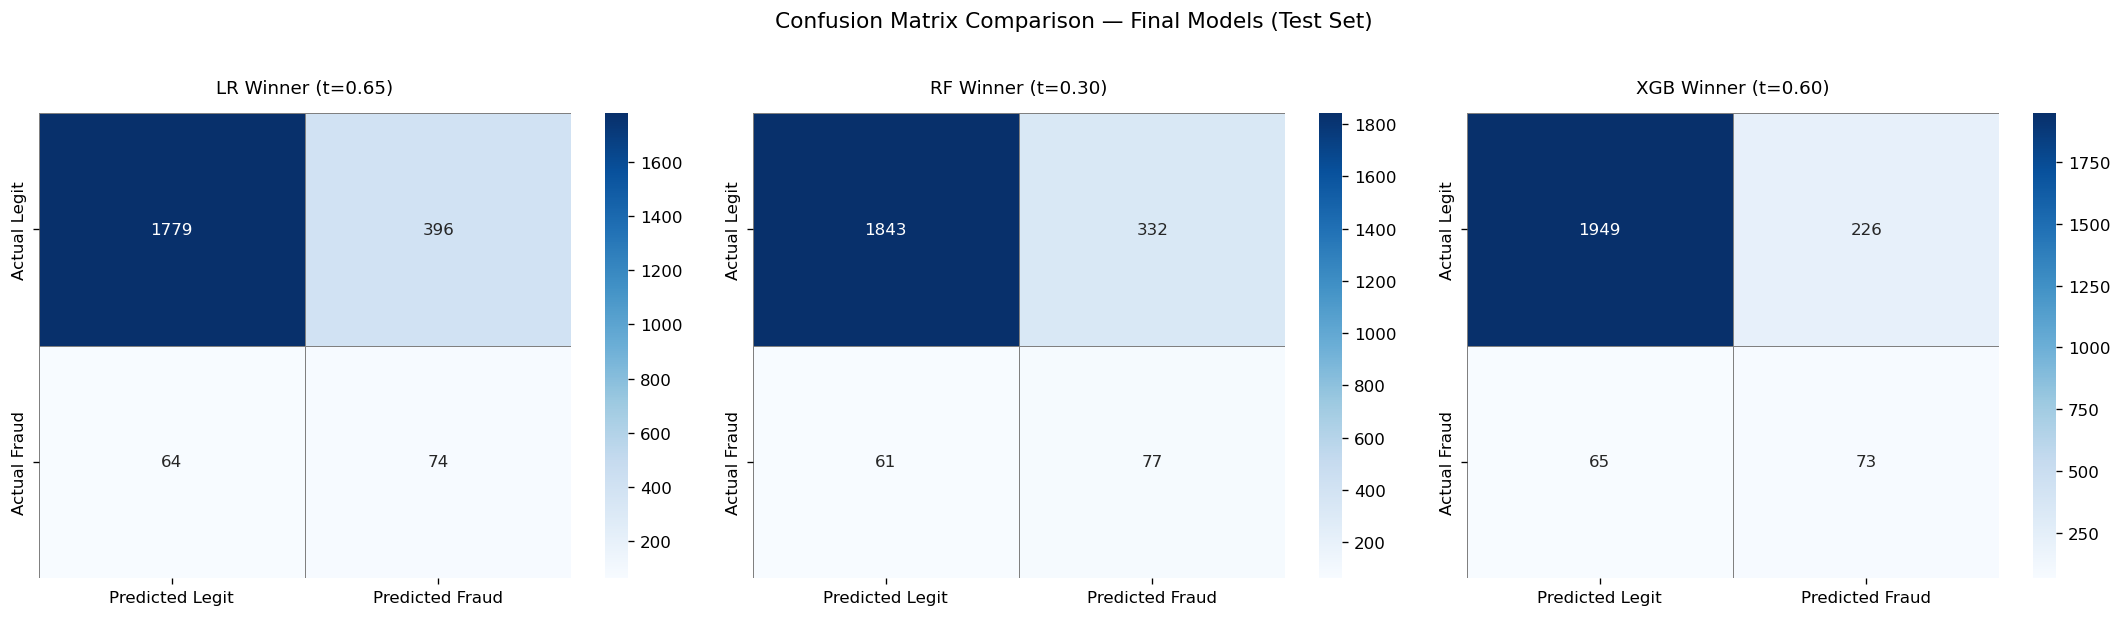

fraudfound
0    2175
1     138
Name: count, dtype: int64


In [280]:
# Compare the confusion matrices of the final selected models on the test set
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

models_final_test = [
    (confusion_matrix(y_test, y_test_pred_lr),  f'LR Winner (t={best_lr_threshold:.2f})'),
    (confusion_matrix(y_test, y_test_pred_rf),  f'RF Winner (t={best_rf_thresh:.2f})'),
    (confusion_matrix(y_test, y_test_pred_xgb), f'XGB Winner (t={best_thresh_tuned:.2f})'),
]

for ax, (cm, title) in zip(axes, models_final_test):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Predicted Legit', 'Predicted Fraud'],
                yticklabels=['Actual Legit', 'Actual Fraud'],
                linewidths=0.5, linecolor='gray', ax=ax)
    ax.set_title(title, fontsize=11, pad=12)

plt.suptitle('Confusion Matrix Comparison — Final Models (Test Set)',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print(y_test.value_counts())  # Show the class distribution in the test set

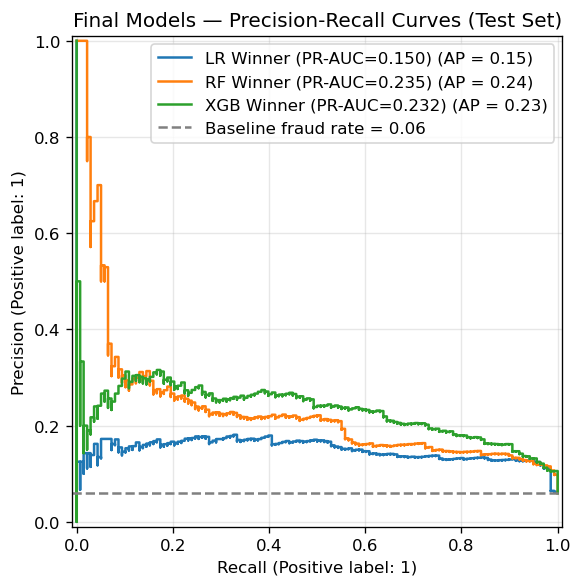

In [282]:
# Plot Precision-Recall curves for the final selected models on the test set
fig, ax = plt.subplots(figsize=(7, 5))

PrecisionRecallDisplay.from_predictions(y_test, y_test_proba_lr,
    name=f"LR Winner (PR-AUC={lr_test_prauc:.3f})", ax=ax)
PrecisionRecallDisplay.from_predictions(y_test, y_test_proba_rf,
    name=f"RF Winner (PR-AUC={rf_test_prauc:.3f})", ax=ax)
PrecisionRecallDisplay.from_predictions(y_test, y_test_proba_xgb,
    name=f"XGB Winner (PR-AUC={xgb_test_prauc:.3f})", ax=ax)

# Add the baseline fraud rate for comparison
fraud_rate = y_test.mean()
ax.axhline(fraud_rate, color="gray", linestyle="--",
           label=f"Baseline fraud rate = {fraud_rate:.2f}")

ax.set_title("Final Models — Precision-Recall Curves (Test Set)")
ax.grid(alpha=0.3)
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()


---
## 14. Final Model Comparison and Results

All models were selected using the validation set with the test set only used once to select the best performing model from the three families.

From the results above, we can clearly see the hierarchy between the three model families. XGBoost Tuned with random oversampling emerged as the best model after having obtained the best performance in terms of PR-AUC of 0.246 and F1 of 0.328 on the test set. Random Forest obtained the best recall of 0.819, meaning that the most number of frauds was correctly detected by the model, however, at the expense of extremely poor precision of 0.133, which means that for every fraud detection, six genuine customers were incorrectly classified as fraudsters. This is why Random Forest is expensive to use in practice despite high recall.

The findings clearly show that the algorithm-level strategies always performed better than the data-level strategies for all the three families of models tested. Class weighting and threshold tuning were more consistent in providing gains compared to SMOTE and oversampling, while hyperparameter tuning offered some gains for XGBoost.

Test set results — final evaluation:

| Model | Threshold | PR-AUC | ROC-AUC | Precision | Recall | F1 |
|---|---|---|---|---|---|---|
| LR Winner (LR-1 Tuned) | 0.65 | 0.150 | 0.799 | 0.157 | 0.536 | 0.243 |
| RF Winner (RF-2 Tuned) | 0.10 | 0.210 | 0.821 | 0.133 | 0.819 | 0.228 |
| XGB Winner (XGB-2 Tuned) | 0.60 | 0.246 | 0.865 | 0.221 | 0.638 | 0.328 |

---
## 15. Reflection on Failures and Limitations

**What went well.** XGBoost with random oversampling and threshold optimisation had the best balance between all four metrics. The coarse to fine search of the hyperparameters was methodically correct and strictly based on the course methodology. Stratification ensured that the percentage of frauds in all splits remained constant, thus avoiding an overly optimistic estimate of the results. Threshold optimisation made a consistent difference in all three model families.

**What did not work.** SMOTE algorithms were ineffective for all three models. In the case of XGBoost, recall was as low as 0.079 due to synthetic data interpolation in categorical features producing non-existent feature combinations in the context of real insurance claims. The model learned from noise instead of learning from real fraud patterns. Recall of SMOTE-NC was slightly better — 0.101 — but still much lower compared to the top model. It proves that the categorical nature of the dataset limits the efficiency of any SMOTE algorithm.

**What surprised us.** Hyperparameter tuning for XGBoost delivered only modest gains — PR-AUC improved by 0.014 after the coarse-to-fine search. This suggests that the choice of model architecture and resampling strategy are more significant drivers of performance than fine-grained parameter optimisation on this dataset. Random Forest achieving the highest recall but the lowest precision was also notable — it demonstrates that optimising for a single metric without considering the precision trade-off produces a model that is operationally difficult to deploy.

**Limitations.** The data was sourced from one source only and contains claims made from 1994 to 1996. It is unlikely that the findings can be applied to cuurent cases of insurance fraud because the modern cases employ digital means of committing fraud. The claimant population is dominated by males and middle-aged individuals, which poses questions about demographic bias, a model in use may end up flagging some particular demographics more often than others. None of the models scored higher than 0.246 in PR-AUC on the testing set.

**Ethical consideration.** Any implementation of the above models as an automated decision-making system is very risky. Wrong positives will falsely identify good customers as fraudsters, creating mistrust and financial loss. Wrong negatives will lead to fraudulent payments passing through. The best way to implement these models is to use them as the first filter system to prioritize claims that require human review and investigation, and not as an autonomous decision-making system.

---
## 16. Group Collaboration

This project was completed collaboratively by all six group members. Contributions were distributed as follows.

Aoi Ueno led the exploratory data analysis, producing statistical summaries, visualisations, and the univariate and bivariate analyses. Estelle Arnander handled the preprocessing pipeline, encoding decisions, and feature engineering, with particular attention to data leakage prevention. José Bouza Femenia was responsible for the Random Forest experiments, hyperparameter tuning, and threshold optimisation for that model family. Loraine Nieto implemented the Logistic Regression experiments, tuning, and evaluation, and also developed the narrative framing of the problem through the storyline connecting results to a real-world insurance context. Manvi Gupta managed pipeline integration, notebook structure, and the final model comparison. Seif Omara implemented the XGBoost experiments, the coarse-to-fine hyperparameter search, threshold optimisation, and the SMOTE-NC extension following reviewer feedback.

Tools used throughout the project included GitHub for version control, Jupyter Notebook for development and documentation, scikit-learn for preprocessing and modelling, XGBoost for gradient boosting, imbalanced-learn for resampling strategies, and pandas, matplotlib, and seaborn for data manipulation and visualisation.

All group members committed their work to GitHub via regular commits. The full commit history is available at the repository link above. If this project were repeated, we would implement SMOTE-NC from the start rather than treating all resampling strategies as equivalent, and we would incorporate cost-sensitive evaluation using real financial weights for false negatives versus false positives earlier in the process.

---
## References

- Angoss Knowledge Seeker. *Vehicle Insurance Fraud Detection Dataset.* Kaggle. https://www.kaggle.com/datasets/khusheekapoor/vehicle-insurance-fraud-detection
- Burkov, A. (2020). *Machine Learning Engineering.* True Positive Inc. ISBN 9781999579579
- Chawla, N. V., Bowyer, K. W., Hall, L. O., & Kegelmeyer, W. P. (2002). SMOTE: Synthetic Minority Over-sampling Technique. *Journal of Artificial Intelligence Research, 16*, 321–357.
- Pedregosa, F. et al. (2011). Scikit-learn: Machine Learning in Python. *JMLR, 12*, 2825–2830.
- Chen, T., & Guestrin, C. (2016). XGBoost: A Scalable Tree Boosting System. *Proceedings of the 22nd ACM SIGKDD International Conference on Knowledge Discovery and Data Mining.*
- Lemaître, G., Nogueira, F., & Aridas, C. K. (2017). Imbalanced-learn: A Python Toolbox to Tackle the Curse of Imbalanced Datasets in Machine Learning. *JMLR, 18*(17), 1–5.